# 目录
- [第一个神经网络](#第一个神经网络)
- [数据处理与加载](#数据处理与加载)
- [卷积神经网络](#卷积神经网络)
- [循环神经网络](#循环神经网络)
- [Transformer](#transformer)
- [Transformer Pytorch 实现](#transformer-pytorch-实现)
- [optim 优化器模块](#optim-优化器模块)
- [torchvision 模块](#torchvision-模块)
- [模型保存与加载](#模型保存与加载)
- [numpy原理](#numpy原理)

---



# 简介
PyTorch 是一个开源的 Python 机器学习库，基于 Torch 库，底层由 C++ 实现，应用于人工智能领域，如计算机视觉和自然语言处理。

许多深度学习软件都是基于 PyTorch 构建的，包括特斯拉自动驾驶、Uber 的 Pyro、Hugging Face 的 Transformers、 PyTorch Lightning 和 Catalyst。

PyTorch 两大特征：

- 类似于 NumPy 的张量计算，能在 GPU 或 MPS 等硬件加速器上加速。
- 基于带自动微分系统的深度神经网络。

PyTorch 包括 torch.autograd、torch.nn、torch.optim 等子模块。

## PyTorch 特性
- **动态计算图（Dynamic Computation Graphs）**  
PyTorch 的计算图是动态的，这意味着它们在运行时构建，并且可以随时改变。这为实验和调试提供了极大的灵活性，因为开发者可以逐行执行代码，查看中间结果。

- **自动微分（Automatic Differentiation）**  
PyTorch 的自动微分系统允许开发者轻松地计算梯度，这对于训练深度学习模型至关重要。它通过反向传播算法自动计算出损失函数对模型参数的梯度。

- **张量计算（Tensor Computation）**  
PyTorch 提供了类似于 NumPy 的张量操作，这些操作可以在 CPU 和 GPU 上执行，从而加速计算过程。张量是 PyTorch 中的基本数据结构，用于存储和操作数据。

**动态计算图（Dynamic Computation Graph）**  

与 TensorFlow 的静态计算图（graph）不同，PyTorch 在执行时构建计算图，这意味着在每次计算时，图都会根据输入数据的形状自动变化。

动态计算图的优点：

- 更加灵活，特别适用于需要条件判断或递归的场景。
- 方便调试和修改，能够直接查看中间结果。
- 更接近 Python 编程的风格，易于上手。

**张量（Tensor）与自动求导（Autograd）**  
PyTorch 中的核心数据结构是 张量（Tensor），它是一个多维矩阵，可以在 CPU 或 GPU 上高效地进行计算。

张量的操作支持自动求导（Autograd）机制，使得在反向传播过程中自动计算梯度，这对于深度学习中的梯度下降优化算法至关重要。

张量（Tensor）：

- 支持在 CPU 和 GPU 之间进行切换。
- 提供了类似 NumPy 的接口，支持元素级运算。
- 支持自动求导，可以方便地进行梯度计算。

自动求导（Autograd）：
- PyTorch 内置的自动求导引擎，能够自动追踪所有张量的操作，并在反向传播时计算梯度。
- 通过 requires_grad 属性，可以指定张量需要计算梯度。
- 支持高效的反向传播，适用于神经网络的训练。

**模型定义与训练**

PyTorch 提供了 torch.nn 模块，允许用户通过继承 nn.Module 类来定义神经网络模型。

使用 forward 函数指定前向传播，自动反向传播（通过 autograd）和梯度计算也由 PyTorch 内部处理。

神经网络模块（torch.nn）：

- 提供了常用的层（如线性层、卷积层、池化层等）。
- 支持定义复杂的神经网络架构（包括多输入、多输出的网络）。
- 兼容与优化器（如 torch.optim）一起使用。

**GPU 加速**
- PyTorch 完全支持在 GPU 上运行，以加速深度学习模型的训练。通过简单的 .to(device) 方法，用户可以将模型和张量转移到 GPU 上进行计算。
- PyTorch 支持多 GPU 训练，能够利用 NVIDIA CUDA 技术显著提高计算效率。

GPU 支持：

- 自动选择 GPU 或 CPU。
- 支持通过 CUDA 加速运算。
- 支持多 GPU 并行计算（DataParallel 或 torch.distributed）。

**生态系统与社区支持**

PyTorch 作为一个开源项目，拥有一个庞大的社区和生态系统。它不仅在学术界得到了广泛的应用，也在工业界，特别是在计算机视觉、自然语言处理等领域中得到了广泛部署。

PyTorch 还提供了许多与深度学习相关的工具和库，如：

- torchvision：用于计算机视觉任务的数据集和模型。
- torchtext：用于自然语言处理任务的数据集和预处理工具。
- torchaudio：用于音频处理的工具包。
- PyTorch Lightning：一种简化 PyTorch 代码的高层库，专注于研究和实验的快速迭代。

# 安装
**支持的操作系统**  
Windows：Windows 10 或更高版本（64位） 

**Python 版本要求**  
推荐版本：Python 3.8 - 3.11  
注意：Python 3.12+ 支持可能有限，建议使用稳定版本  

**硬件要求**  
CPU：支持 SSE4.2 指令集的 x86_64 处理器  
内存：至少 4GB RAM（推荐 8GB+）  
存储：至少 3GB 可用空间  
GPU（可选）：NVIDIA GPU with CUDA Compute Capability 3.5+ 

**CUDA 兼容性（GPU 版本）**
|PyTorch 版本	|支持的 CUDA 版本	|推荐 CUDA 版本|
|---|---|---|
|2.1.x	        |11.8, 12.1	        |12.1|
|2.0.x	        |11.7, 11.8	        |11.8|
|1.13.x	        |11.6, 11.7	        |11.7|

**检查系统信息**  
Windows:  
- 检查 Windows 版本  
winver  

- 检查 Python 版本  
python --version  

- 检查是否有 NVIDIA GPU  
nvidia-smi  

**Python 环境管理**  
1. 使用 Anaconda/Miniconda:
>```
># 下载并安装 Miniconda
># Windows: https://repo.anaconda.com/miniconda/Miniconda3-latest-Windows-x86_64.exe
>
># 创建专用环境
>conda create -n pytorch_env python=3.10
>conda activate pytorch_env
>```

2. 使用 venv（Python 自带）
>```
># 创建虚拟环境
>python -m venv pytorch_env
>
># 激活环境
># Windows
>pytorch_env\Scripts\activate
>```

## Miniconda
**Miniconda安装与配置**  
略  

**Miniconda安装检查**  
>```
>C:\Users\LENOVO>conda -V
>conda 25.7.0
>```

**Miniconda使用**  
打开 Anaconda Prompt 或 VSCode 终端  
在 VSCode 中：  
按 Ctrl+ ` 打开终端。  
确保终端类型为 Cmd（非 PowerShell 或 WSL）  
此时可以输入如下命令

列出所有的虚拟环境（默认情况下安装完该软件后会自带一个名为base的虚拟环境）  
conda env list  

进入某个虚拟环境  
conda activate base  

退出当前虚拟环境  
conda deactivate   

创建新的虚拟环境（其中的python311为虚拟环境的名字，可以随便命名（非中文）；3.11为指定的Python版本（也可以修改为其他版本）），过程中需要输入y 确认：  
conda create -n python311 python=3.11  

输入 python-V 可以看到该虚拟环境的版本  

## CUDA
支持GPU版本的PyTorch

**查看现有的CUDA版本**
>```
>C:\Users\LENOVO>nvidia-smi
>Sat Sep 13 16:09:16 2025
>+---------------------------------------------------------------------------------------+
>| NVIDIA-SMI 546.92                 Driver Version: 546.92       CUDA Version: 12.3     |
>|-----------------------------------------+----------------------+----------------------+
>| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
>| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
>|                                         |                      |               MIG M. |
>|=========================================+======================+======================|
>|   0  NVIDIA GeForce RTX 4060 ...  WDDM  | 00000000:01:00.0  On |                  N/A |
>| N/A   38C    P5               8W / 125W |   1311MiB /  8188MiB |      0%      Default |
>|                                         |                      |                  N/A |
>+-----------------------------------------+----------------------+----------------------+
>```
记住这个CUDA的版本，后面安装CUDA的版本要小于等于这个版本  

**检查CUDA安装**
>```
>C:\Users\LENOVO>nvcc -V
>nvcc: NVIDIA (R) Cuda compiler driver
>Copyright (c) 2005-2025 NVIDIA Corporation
>Built on Wed_Jul_16_20:06:48_Pacific_Daylight_Time_2025
>Cuda compilation tools, release 13.0, V13.0.48
>Build cuda_13.0.r13.0/compiler.36260728_0
>```

## Pytorch安装 
PyTorch 官方提供了几种安装方法，可以通过 pip 或 conda 进行安装。  

**CPU 版本安装**

**GPU 版本安装（CUDA）**  
安装 PyTorch GPU 版本:
>```
># CUDA 12.1 版本
>pip install torch torchvision torchaudio
>
># CUDA 11.8 版本
>pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
>
># 使用 conda
>conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
>
># 我用的
>conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
>```

**验证安装**  

In [1]:
import torch

# 当前安装的 PyTorch 库的版本
print(torch.__version__)
# 检查 CUDA 是否可用，即你的系统有 NVIDIA 的 GPU
print(torch.cuda.is_available())
# 检查可用的 CUDA 设备数量
print(torch.cuda.device_count())

# 检查当前 CUDA 设备的名称
print(torch.cuda.get_device_name(0))

2.5.1
True
1
NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
import torch
x = torch.rand(5, 3)
print(x)

tensor([[0.3518, 0.8576, 0.8861],
        [0.2294, 0.0713, 0.5233],
        [0.4527, 0.6828, 0.4074],
        [0.6627, 0.6891, 0.5223],
        [0.5782, 0.3445, 0.2649]])


# 基础
PyTorch 是一个开源的深度学习框架，以其灵活性和动态计算图而广受欢迎。

PyTorch 主要有以下几个基础概念：

- **张量（Tensor）**：PyTorch 的核心数据结构，支持多维数组，并可以在 CPU 或 GPU 上进行加速计算。

- **自动求导（Autograd）**：PyTorch 提供了自动求导功能，可以轻松计算模型的梯度，便于进行反向传播和优化。

- **神经网络（nn.Module）**：PyTorch 提供了简单强大的 API 来构建神经网络模型，可以方便地进行前向传播和模型定义。

- **优化器（Optimizers）**：使用优化器来更新模型的参数，使损失最小化。

- **设备（Device）**：可以将模型和张量移动到 GPU 上加速计算。

## PyTorch 架构总览
PyTorch 架构图
>```
>┌─────────────────────────────────────────────────────────────┐
>│                    PyTorch 生态系统                          │
>├─────────────────────────────────────────────────────────────┤
>│  torchvision  │  torchtext  │  torchaudio  │  其他专业库     │
>├─────────────────────────────────────────────────────────────┤
>│                     PyTorch 核心                             │
>├───────────────┬─────────────────┬───────────────────────────┤
>│   torch.nn    │   torch.optim   │      torch.utils          │
>│   (神经网络)   │   (优化器)      │      (工具函数)            │
>├───────────────┼─────────────────┼───────────────────────────┤
>│               │                 │   torch.utils.data        │
>│  torch 核心   │  autograd       │   (数据加载)               │
>│  (张量计算)    │  (自动微分)     │                            │
>└───────────────┴─────────────────┴───────────────────────────┘
>```
PyTorch 采用分层架构设计，从上层到底层依次为：

1、Python API（顶层）
- torch：核心张量计算（类似NumPy，支持GPU）。
- torch.nn：神经网络层、损失函数等。
- torch.autograd：自动微分（反向传播）。
- 开发者直接调用的接口，简单易用。

2、C++核心（中层）
- ATen：张量运算核心库（400+操作）。
- JIT：即时编译优化模型。
- Autograd引擎：自动微分的底层实现。
- 高性能计算，连接Python与底层硬件。

3、基础库（底层）
- TH/THNN：C语言实现的基础张量和神经网络操作。
- THC/THCUNN：对应的CUDA（GPU）版本。
- 直接操作硬件（CPU/GPU），极致优化速度。

执行流程：  
Python代码 → C++核心计算 → 底层CUDA/C库加速 → 返回结果。  
既保持易用性，又确保高性能。  

## 张量
张量是 PyTorch 中的核心数据结构，用于存储和操作多维数组。

张量可以视为一个多维数组，支持加速计算的操作。

在 PyTorch 中，张量的概念类似于 NumPy 中的数组，但是 PyTorch 的张量可以运行在不同的设备上，比如 CPU 和 GPU。

- 维度（Dimensionality）：张量的维度指的是数据的多维数组结构。  

- 形状（Shape）：张量的形状是指每个维度上的大小。例如，一个形状为(3, 4)的张量意味着它有3行4列。

- 数据类型（Dtype）：张量中的数据类型定义了存储每个元素所需的内存大小和解释方式。  
  PyTorch支持多种数据类型，包括整数型（如torch.int8、torch.int32）、浮点型（如torch.float32、torch.float64）和布尔型（torch.bool）。

### 创建张量

In [ ]:
import torch
import numpy as np

# 创建一个 2x3 的全 0 张量
a = torch.zeros(2, 3)
print(a)

# 创建一个 2x3 的全 1 张量
b = torch.ones(2, 3)
print(b)

# 创建一个 2x3 的随机数张量,数值服从标准正态分布
c = torch.randn(2, 3)
print(c)

# 从 NumPy 数组创建张量
numpy_array = np.array([[1, 2], [3, 4]])
tensor_from_numpy = torch.from_numpy(numpy_array)
print(tensor_from_numpy)

# 在指定设备（CPU/GPU）上创建张量
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
d = torch.randn(2, 3, device=device)
print(d)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[ 0.0894,  1.1984,  0.9955],
        [-1.0854, -0.5431, -0.1808]])
tensor([[1, 2],
        [3, 4]])
tensor([[-0.8520, -0.9173, -0.7029],
        [-0.8879,  0.8097,  0.0214]], device='cuda:0')


### 常用张量操作

In [ ]:
# 张量相加
e = torch.randn(2, 3)
f = torch.randn(2, 3)
print(e + f)

# 逐元素乘法
print(e * f)

# 张量的转置
g = torch.randn(3, 2)
print(g.t())  # 或 g.transpose(0, 1)

# 张量的形状
print(g.shape)  # 返回形状

### 张量与设备
PyTorch 张量可以存在于不同的设备上，包括CPU和GPU，你可以将张量移动到 GPU 上以加速计算：
>```py
>if torch.cuda.is_available():
>    tensor_gpu = tensor_from_list.to('cuda')  # 将张量移动到GPU

### 梯度和自动微分
当你创建一个需要梯度的张量时，PyTorch可以自动计算其梯度：

In [ ]:
# 创建一个需要梯度的张量
tensor_requires_grad = torch.tensor([1.0], requires_grad=True)

# 进行一些操作
tensor_result = tensor_requires_grad * 2

# 计算梯度
tensor_result.backward()
print(tensor_requires_grad.grad) # 输出梯度tensor([2.])

In [ ]:
x = torch.tensor([1.0], requires_grad=True)
y = x * 3
z = y + torch.tensor([5.0])
z.backward()

print(x.grad)  # 输出：tensor([3.])

# dz/dx = dz/dy * dy/dx = 1 * 3 = 3

### 内存和性能
PyTorch 张量还提供了一些内存管理功能，比如.clone()、.detach() 和 .to() 方法，它们可以帮助你优化内存使用和提高性能。

## 自动求导
在深度学习中，自动求导主要用于两个方面：一是在训练神经网络时计算梯度，二是进行反向传播算法的实现。自动求导基于链式法则

**动态图与静态图：**

- **动态图（Dynamic Graph）**：计算图在运行时动态构建。每次执行操作时，计算图都会更新，这使得调试和修改模型变得更加容易。PyTorch使用的是动态图。

- **静态图（Static Graph）**：在静态图中，计算图在开始执行之前构建完成，并且不会改变。TensorFlow最初使用的是静态图，后来也支持动态图。

PyTorch 通过 autograd 模块来自动计算梯度。

torch.Tensor 对象有一个 requires_grad 属性。

当你创建一个 requires_grad=True 的张量时，PyTorch 会自动跟踪所有对它的操作，以便在之后计算梯度。

In [ ]:
# 创建一个需要计算梯度的张量
x = torch.randn(2, 2, requires_grad=True)
print(x)

# 执行某些操作
y = x + 2 # 每个值都加2，y 自动继承 x 的梯度属性：y.requires_grad = True
# print(y)
z = y **2 * 3
# print(z)
out = z.mean()

print(out)

tensor([[ 0.3825,  0.9558],
        [ 0.5814, -0.5487]], requires_grad=True)
tensor(17.3876, grad_fn=<MeanBackward0>)


### 反向传播
一旦定义了计算图，可以通过 .backward() 方法来计算梯度

反向传播是一种通过计算损失函数关于网络参数的梯度来训练神经网络的方法。

在每次迭代中，网络的前向传播会计算输出和损失，然后反向传播会计算损失关于每个参数的梯度，并使用这些梯度来更新参数

In [7]:
# 反向传播，计算梯度
out.backward()

# 查看 x 的梯度
print(x.grad) # x的梯度 = 6y / 4 = 1.5 (x + 2)

tensor([[3.5738, 4.4338],
        [3.8721, 2.1770]])


### 停止梯度计算
使用 torch.no_grad() 或设置 requires_grad=False。

In [ ]:
# 使用 torch.no_grad() 禁用梯度计算
with torch.no_grad():
    y = x * 2

## 神经网络（nn.Module）
我们可以继承 nn.Module 类并定义自己的网络层。

nn.Module 是所有神经网络模块的基类，你需要定义以下两个部分：

- `__init__()`：定义网络层。
- `forward()`：定义数据的前向传播过程。

In [8]:
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的全连接神经网络
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)  # 输入层到隐藏层
        self.fc2 = nn.Linear(2, 1)  # 隐藏层到输出层
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # ReLU 激活函数
        x = self.fc2(x)
        return x

# 创建网络实例
model = SimpleNN()

# 打印模型结构
print(model)

SimpleNN(
  (fc1): Linear(in_features=2, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=1, bias=True)
)


### 前向传播与损失计算

In [9]:
# 随机输入
x = torch.randn(1, 2)

# 前向传播
output = model(x)
print(output)

# 定义损失函数（例如均方误差 MSE）
criterion = nn.MSELoss()

# 假设目标值为 1
target = torch.randn(1, 1)

# 计算损失
loss = criterion(output, target)
print(loss)

tensor([[0.1482]], grad_fn=<AddmmBackward0>)
tensor(1.4575, grad_fn=<MseLossBackward0>)


## 优化器
PyTorch 提供了多种优化器，例如 SGD、Adam 等。

In [ ]:
# 定义优化器（使用 Adam 优化器）
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练步骤
optimizer.zero_grad()  # 清空梯度
loss.backward()  # 反向传播
optimizer.step()  # 更新参数

## 设备
使用 torch.device 来指定计算设备

在训练过程中，所有张量和模型都应该移到同一个设备上（要么都在 CPU 上，要么都在 GPU 上）。
>```py
>device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
>
># 将模型移动到设备
>model.to(device)
>
># 将数据移动到设备
>X = X.to(device)
>Y = Y.to(device)

## 层
PyTorch 提供了许多常见的神经网络层，以下是几个常见的：
- nn.Linear(in_features, out_features)：全连接层，输入 in_features 个特征，输出 out_features 个特征。
- nn.Conv2d(in_channels, out_channels, kernel_size)：2D 卷积层，用于图像处理。
- nn.MaxPool2d(kernel_size)：2D 最大池化层，用于降维。
- nn.ReLU()：ReLU 激活函数，常用于隐藏层。
- nn.Softmax(dim)：Softmax 激活函数，通常用于输出层，适用于多类分类问题。

## 激活函数
激活函数决定了神经元是否应该被激活。它们是非线性函数，使得神经网络能够学习和执行更复杂的任务。常见的激活函数包括：

- Sigmoid：用于二分类问题，输出值在 0 和 1 之间。
- Tanh：输出值在 -1 和 1 之间，常用于输出层之前。
- ReLU（Rectified Linear Unit）：目前最流行的激活函数之一，定义为 f(x) = max(0, x)，有助于解决梯度消失问题。
- Softmax：常用于多分类问题的输出层，将输出转换为概率分布。

## 损失函数
常见的损失函数包括：

- 均方误差（MSELoss）：回归问题常用，计算输出与目标值的平方差。
- 交叉熵损失（CrossEntropyLoss）：分类问题常用，计算输出和真实标签之间的交叉熵。
- BCEWithLogitsLoss：二分类问题，结合了 Sigmoid 激活和二元交叉熵损失。

In [ ]:
# 均方误差损失
criterion = nn.MSELoss()

# 交叉熵损失
criterion = nn.CrossEntropyLoss()

# 二分类交叉熵损失
criterion = nn.BCEWithLogitsLoss()

## 优化器
优化器负责在训练过程中更新网络的权重和偏置。

常见的优化器包括：

- SGD（随机梯度下降）
- Adam（自适应矩估计）
- RMSprop（均方根传播）

In [ ]:
# 使用SGD优化器
optimizer = optim.SGD(model.parameters,lr=0.01)

# 使用Adam优化器
optimizer = optim.Adam(model.parameters,lr=0.001)

# 使用RMSprop优化器
optimizer = optim.RMSprop(model.parameters,lr=0.01)

## 训练过程
训练神经网络涉及以下步骤：

1. 准备数据：通过 DataLoader 加载数据。
2. 定义损失函数和优化器。
3. 前向传播：计算模型的输出。
4. 计算损失：与目标进行比较，得到损失值。
5. 反向传播：通过 loss.backward() 计算梯度。
6. 更新参数：通过 optimizer.step() 更新模型的参数。
7. 重复上述步骤，直到达到预定的训练轮数。

In [ ]:
# 训练数据示例
X = torch.randn(10, 2)  # 10 个样本，每个样本有 2 个特征
Y = torch.randn(10, 1)  # 10 个目标标签

# 训练过程
for epoch in range(100):  # 训练 100 轮
    model.train()  # 设置模型为训练模式
    optimizer.zero_grad()  # 清除梯度
    output = model(X)  # 前向传播
    loss = criterion(output, Y)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新权重
   
    if (epoch + 1) % 10 == 0:  # 每 10 轮输出一次损失
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')

## 测试与评估
训练完成后，需要对模型进行测试和评估。

常见的步骤包括：

- 计算测试集的损失：测试模型在未见过的数据上的表现。
- 计算准确率（Accuracy）：对于分类问题，计算正确预测的比例。  

>```py
># 假设你有测试集 X_test 和 Y_test
>model.eval()  # 设置模型为评估模式
>with torch.no_grad():  # 在评估过程中禁用梯度计算
>    output = model(X_test)
>    loss = criterion(output, Y_test)
>    print(f'Test Loss: {loss.item():.4f}')
>```

## 训练模型步骤
1. 数据准备：
  - 收集和处理数据，包括清洗、标准化和归一化。
  - 将数据分为训练集、验证集和测试集。

2. 定义模型：
  - 选择模型架构，例如决策树、神经网络等。
  - 初始化模型参数（权重和偏置）。

3. 选择损失函数：
  - 根据任务类型（如分类、回归）选择合适的损失函数。

4. 选择优化器：
  - 选择一个优化算法，如SGD、Adam等，来更新模型参数。

5. 前向传播：
  - 在每次迭代中，将输入数据通过模型传递，计算预测输出。

6. 计算损失：
  - 使用损失函数评估预测输出与真实标签之间的差异。

7. 反向传播：
  - 利用自动求导计算损失相对于模型参数的梯度。

8. 参数更新：
  - 根据计算出的梯度和优化器的策略更新模型参数。

9. 迭代优化：
  - 重复步骤5-8，直到模型在验证集上的性能不再提升或达到预定的迭代次数。

10. 评估和测试：
  - 使用测试集评估模型的最终性能，确保模型没有过拟合。

11. 模型调优：
  - 根据模型在测试集上的表现进行调参，如改变学习率、增加正则化等。

12. 部署模型：
  - 将训练好的模型部署到生产环境中，用于实际的预测任务。

## 简单神经网络模型

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 定义一个简单的神经网络模型
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)  # 输入层到隐藏层
        self.fc2 = nn.Linear(2, 1)  # 隐藏层到输出层
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # ReLU 激活函数
        x = self.fc2(x)
        return x

# 2. 创建模型实例
model = SimpleNN()

# 3. 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器

# 4. 假设我们有训练数据 X 和 Y
X = torch.randn(10, 2)  # 10 个样本，2 个特征
Y = torch.randn(10, 1)  # 10 个目标值

# 5. 训练循环
for epoch in range(100):  # 训练 100 轮
    optimizer.zero_grad()  # 清空之前的梯度
    output = model(X)  # 前向传播
    loss = criterion(output, Y)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新参数
    
    # 每 10 轮输出一次损失
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

# 张量
![image.png](https://www.runoob.com/wp-content/uploads/2024/12/1__D5ZvufDS38WkhK9rK32hQ.jpg)


## 创建张量

| 方法 | 说明 | 示例代码 |
|------|------|----------|
| `torch.tensor(data)` | 从 Python 列表或 NumPy 数组创建张量 | `x = torch.tensor([[1, 2], [3, 4]])` |
| `torch.zeros(size)` | 创建一个全为零的张量 | `x = torch.zeros((2, 3))` |
| `torch.ones(size)` | 创建一个全为 1 的张量 | `x = torch.ones((2, 3))` |
| `torch.empty(size)` | 创建一个未初始化的张量（内容随机） | `x = torch.empty((2, 3))` |
| `torch.rand(size)` | 创建服从均匀分布的随机张量（范围 [0, 1)） | `x = torch.rand((2, 3))` |
| `torch.randn(size)` | 创建服从正态分布的随机张量（均值 0，标准差 1） | `x = torch.randn((2, 3))` |
| `torch.arange(start, end, step)` | 创建一维序列张量（类似 Python 的 `range`） | `x = torch.arange(0, 10, 2)` |
| `torch.linspace(start, end, steps)` | 创建指定范围内等间隔的序列张量 | `x = torch.linspace(0, 1, 5)` |
| `torch.eye(size)` | 创建单位矩阵（对角线为 1，其余为 0） | `x = torch.eye(3)` |
| `torch.from_numpy(ndarray)` | 将 NumPy 数组转换为张量 | `x = torch.from_numpy(np.array([1, 2, 3]))` |

In [ ]:
import torch

# 创建 2D 张量（矩阵）
tensor_2d = torch.tensor([
    [-9, 4, 2, 5, 7],
    [3, 0, 12, 8, 6],
    [1, 23, -6, 45, 2],
    [22, 3, -1, 72, 6]
])
print("2D Tensor (Matrix):\n", tensor_2d)
print("Shape:", tensor_2d.shape)  

# 创建 3D 张量（立方体）
tensor_3d = torch.stack([tensor_2d, tensor_2d + 10, tensor_2d - 5])  # 堆叠 3 个 2D 张量
print("3D Tensor (Cube):\n", tensor_3d)
print("Shape:", tensor_3d.shape)  # 形状

# 创建 4D 张量（向量的立方体）
tensor_4d = torch.stack([tensor_3d, tensor_3d + 10])  # 堆叠 2 个 3D 张量
print("4D Tensor (Vector of Cubes):\n", tensor_4d)
print("Shape:", tensor_4d.shape)  # 形状

# 创建 5D 张量（矩阵的立方体）
tensor_5d = torch.stack([tensor_4d, tensor_4d -10])  # 堆叠 2 个 4D 张量
print("5D Tensor (Matrix of Cubes):\n", tensor_5d)
print("Shape:", tensor_5d.shape)  # 形状

## 张量的属性
| 属性 | 说明 | 示例 |
|------|------|------|
| `.shape` | 获取张量的形状（返回 `torch.Size` 对象） | `tensor.shape` |
| `.size()` | 获取张量的形状（功能同 `.shape`，返回元组） | `tensor.size()` |
| `.dtype` | 获取张量的数据类型（如 `torch.float32`） | `tensor.dtype` |
| `.device` | 查看张量所在的设备（`cpu` 或 `cuda:0`） | `tensor.device` |
| `.dim()` | 获取张量的维度数（如 2D 张量返回 2） | `tensor.dim()` |
| `.requires_grad` | 是否启用梯度计算（`True`/`False`） | `tensor.requires_grad` |
| `.numel()` | 获取张量中的元素总数（如 2x3 张量返回 6） | `tensor.numel()` |
| `.is_cuda` | 检查张量是否在 GPU 上（`True`/`False`） | `tensor.is_cuda` |
| `.T` | 获取张量的转置（仅适用于 2D 张量） | `tensor.T` |
| `.item()` | 获取单元素张量的 Python 标量值 | `tensor.item()` |
| `.is_contiguous()` | 检查张量是否连续存储（影响某些操作效率） | `tensor.is_contiguous()` |

In [ ]:
tensor=torch.tensor(([1,2,3],[4,5,6]),dtype=torch.float32)

# 张量的属性
print("Tensor:\n", tensor)
print("Shape:", tensor.shape)  # 获取形状
print("Size:", tensor.size())  # 获取形状（另一种方法）
print("Data Type:", tensor.dtype)  # 数据类型
print("Device:", tensor.device)  # 设备
print("Dimensions:", tensor.dim())  # 维度数
print("Total Elements:", tensor.numel())  # 元素总数
print("Requires Grad:", tensor.requires_grad)  # 是否启用梯度
print("Is CUDA:", tensor.is_cuda)  # 是否在 GPU 上
print("Is Contiguous:", tensor.is_contiguous())  # 是否连续存储

# 获取单元素值
single_value = torch.tensor(42)
print("Single Element Value:", single_value.item())

# 转置张量
print("Transposed Tensor:\n", tensor.T)

## 张量的操作

### **基础操作**
| 操作 | 说明 | 示例代码 |
|------|------|----------|
| `+`, `-`, `*`, `/` | 元素级加法、减法、乘法、除法 | `z = x + y` |
| `torch.matmul(x, y)` | 矩阵乘法 | `z = torch.matmul(x, y)` |
| `torch.dot(x, y)` | 向量点积（仅适用于 1D 张量） | `z = torch.dot(x, y)` |
| `torch.sum(x)` | 求和 | `z = torch.sum(x)` |
| `torch.mean(x)` | 求均值 | `z = torch.mean(x)` |
| `torch.max(x)` | 求最大值 | `z = torch.max(x)` |
| `torch.min(x)` | 求最小值 | `z = torch.min(x)` |
| `torch.argmax(x, dim)` | 返回最大值的索引（指定维度） | `z = torch.argmax(x, dim=1)` |
| `torch.softmax(x, dim)` | 计算 softmax（指定维度） | `z = torch.softmax(x, dim=1)` |

### **形状操作**
| 操作 | 说明 | 示例代码 |
|------|------|----------|
| `x.view(shape)` | 改变张量的形状（不改变数据） | `z = x.view(3, 4)` |
| `x.reshape(shape)` | 类似于 `view`，但更灵活（自动处理内存连续性） | `z = x.reshape(3, 4)` |
| `x.t()` | 转置矩阵（仅适用于 2D 张量） | `z = x.t()` |
| `x.unsqueeze(dim)` | 在指定维度添加一个维度（如 `dim=0` 添加批次维度） | `z = x.unsqueeze(0)` |
| `x.squeeze(dim)` | 去掉指定维度为 1 的维度（如 `dim=0` 移除批次维度） | `z = x.squeeze(0)` |
| `torch.cat((x, y), dim)` | 按指定维度连接多个张量（如 `dim=1` 水平拼接） | `z = torch.cat((x, y), dim=1)` |

In [ ]:
tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
print("原始张量:\n", tensor)

# 1. **索引和切片操作**
print("\n【索引和切片】")
print("获取第一行:", tensor[0])  # 获取第一行
print("获取第一行第一列的元素:", tensor[0, 0])  # 获取特定元素
print("获取第二列的所有元素:", tensor[:, 1])  # 获取第二列所有元素

# 2. **形状变换操作**
print("\n【形状变换】")
reshaped = tensor.view(3, 2)  # 改变张量形状为 3x2
print("改变形状后的张量:\n", reshaped)
flattened = tensor.flatten()  # 将张量展平成一维
print("展平后的张量:\n", flattened)

# 3. **数学运算操作**
print("\n【数学运算】")
tensor_add = tensor + 10  # 张量加法
print("张量加 10:\n", tensor_add)
tensor_mul = tensor * 2  # 张量乘法
print("张量乘 2:\n", tensor_mul)
tensor_sum = tensor.sum()  # 计算所有元素的和
print("张量元素的和:", tensor_sum.item())

# 4. **与其他张量的操作**
print("\n【与其他张量操作】")
tensor2 = torch.tensor([[1, 1, 1], [1, 1, 1]], dtype=torch.float32)
print("另一个张量:\n", tensor2)
tensor_dot = torch.matmul(tensor, tensor2.T)  # 张量矩阵乘法
print("矩阵乘法结果:\n", tensor_dot)

# 5. **条件判断和筛选**
print("\n【条件判断和筛选】")
mask = tensor > 3  # 创建一个布尔掩码
print("大于 3 的元素的布尔掩码:\n", mask)
filtered_tensor = tensor[tensor > 3]  # 筛选出符合条件的元素
print("大于 3 的元素:\n", filtered_tensor)

## 张量的 GPU 加速

In [ ]:
# 将张量转移到 GPU：
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x = torch.tensor([1.0, 2.0, 3.0], device=device)

# 检查 GPU 是否可用：
torch.cuda.is_available()  # 返回 True 或 False

## 张量与 NumPy 的互操作
|操作	                        |说明	                                    |示例代码|
|---|---|---|
|``torch.from_numpy(ndarray)``	|将 NumPy 数组转换为张量。	                 |``x = torch.from_numpy(np_array)``|
|``x.numpy()``	                |将张量转换为 NumPy 数组（仅限 CPU 张量）。	  |``np_array = x.numpy()``|

In [ ]:
# NumPy 数组转换为 PyTorch 张量
numpy_array = np.array([[1, 2, 3], [4, 5, 6]])
tensor_from_numpy = torch.from_numpy(numpy_array)


# 修改 NumPy 数组，张量夜随之变化（共享内存）
numpy_array[0, 0] = 100
print("修改后的 NumPy 数组:\n", numpy_array)
print("PyTorch 张量也会同步变化:\n", tensor_from_numpy)

In [ ]:
# PyTorch 张量转换为 NumPy 数组
tensor = torch.tensor([[7, 8, 9], [10, 11, 12]], dtype=torch.float32)
numpy_from_tensor = tensor.numpy()


# 修改张量，观察 NumPy 数组也随之变化（共享内存）
tensor[0, 0] = 77
print("修改后的 PyTorch 张量:\n", tensor)
print("NumPy 数组也会同步变化:\n", numpy_from_tensor)

In [ ]:
# 注意：不共享内存的情况（需要复制数据）
# 使用 clone() 保证独立数据
tensor_independent = torch.tensor([[13, 14, 15], [16, 17, 18]], dtype=torch.float32)
numpy_independent = tensor_independent.clone().numpy()  # 使用 clone 复制数据

print("原始张量:\n", tensor_independent)
tensor_independent[0, 0] = 0  # 修改张量数据
print("修改后的张量:\n", tensor_independent)
print("NumPy 数组（不会同步变化）:\n", numpy_independent)

# 第一个神经网络

## 示例一
用 PyTorch 实现一个简单的前馈神经网络，完成一个二分类任务。

网络结构包括输入层、隐藏层和输出层，使用了 ReLU 激活函数和 Sigmoid 激活函数。

采用了均方误差损失函数和随机梯度下降优化器。

训练过程是通过前向传播、计算损失、反向传播和参数更新来逐步调整模型参数。

In [11]:
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

x = torch.randn(10,10) # 随机生成输入数据，每个批次10个样本，每个样本10个特征
y = torch.tensor([[1.0], [0.0], [0.0],
                 [1.0], [1.0], [1.0], [0.0], [0.0], [1.0], [1.0]])  # 目标输出数据

# 创建顺序模型，包含线性层、ReLU激活函数和Sigmoid激活函数
model = nn.Sequential(
    nn.Linear(10,5), # 输入层大小为 10，即每个数据点有 10 个特征。隐藏层大小为 5，即隐藏层包含 5 个神经元。
    nn.ReLU(),       # 
    nn.Linear(5,1),  # 输出层大小为 1，即输出一个标量，表示二分类结果（0 或 1）。
    nn.Sigmoid()     # 
)

# 定义均方误差损失函数和随机梯度下降优化器
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.01) # 学习率为0.01

# 用于存储每轮的损失值
losses = []

for epoch in range(50):                             # 迭代50次
    y_pred=model(x)                                 # 前向传播，计算预测值
    loss=criterion(y_pred,y)                        # 计算损失
    losses.append(loss.item())                      # 记录损失值
    if (epoch+1)%10==0:
        print(f'Epoch: {epoch+1}/50  loss: {loss.item()}')  # 打印损失值

    optimizer.zero_grad()                           # 清零梯度
    loss.backward()                                 # 反向传播，计算梯度
    optimizer.step()                                # 更新模型参数

Epoch: 10/50  loss: 0.2503773868083954
Epoch: 20/50  loss: 0.24943578243255615
Epoch: 30/50  loss: 0.24852649867534637
Epoch: 40/50  loss: 0.24764713644981384
Epoch: 50/50  loss: 0.24680039286613464


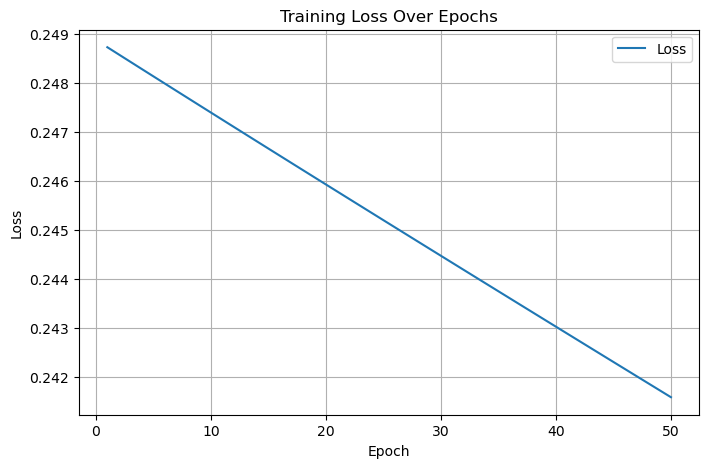

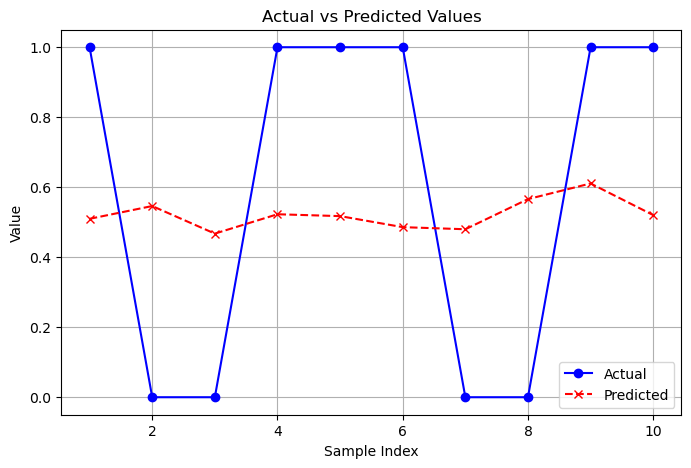

In [9]:
# 可视化损失变化曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()

# 可视化预测结果与实际目标值对比
y_pred_final = model(x).detach().numpy() # 最终预测值
y_actual = y.numpy() # 实际值

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10 + 1), y_actual, 'o-', label='Actual', color='blue')
plt.plot(range(1, 10 + 1), y_pred_final, 'x--', label='Predicted', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid()
plt.show()

## 示例二
假设有一个二维数据集，目标是根据点的位置将它们分类到两个类别中（例如，红色和蓝色点）。

以下展示了如何使用神经网络完成简单的二分类任务，通过 PyTorch 的模块化接口，神经网络的构建、训练和可视化都非常直观。

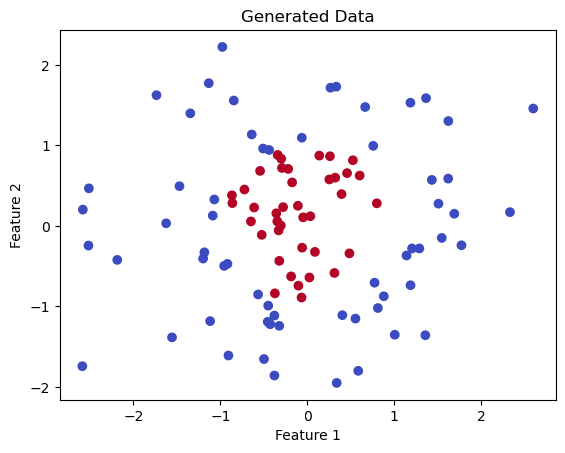

In [2]:
import torch
from torch import nn
from torch import optim
from matplotlib import pyplot as plt

data = torch.randn(100,2) # 生成100个2维数据
labels = (data[:,0]**2 + data[:,1]**2 < 1).float().unsqueeze(1) # 点在圆内为1，圆外为0
# .float() 将布尔型张量转换为浮点型张量（True → 1.0，False → 0.0），形状仍为 (100,)。
# nsqueeze(dim) 的作用是在指定维度 dim 上增加一个长度为 1 的维度。原始形状 (100,) → 扩展后形状 (100, 1)。

# 可视化数据
plt.scatter(data[:, 0], data[:, 1], c=labels.squeeze(), cmap='coolwarm')
plt.title("Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [10]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__() # 链式调用父类的初始化函数
        self.fc1 = nn.Linear(2,4) # 输入层有 2 个特征，隐藏层有 4 个神经元
        self.fc2 = nn.Linear(4,1) # 隐藏层输出到 1 个神经元（用于二分类）
        self.sigmoid = nn.Sigmoid() # 二分类激活函数

    def forward(self,x):
        x = torch.relu(self.fc1(x))  # 使用 ReLU 激活函数
        x = self.sigmoid(self.fc2(x)) # 输出层使用 Sigmoid 激活函数
        return x
# 实例化模型    
model = SimpleNN()    

criterion = nn.BCELoss() # 二元交叉熵损失
optimizer = optim.SGD(model.parameters(),lr=0.1) # 

epochs = 100
for epoch in range(epochs):
    # 前向传播
    outputs = model(data)
    loss = criterion(outputs,labels)

    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 每 10 轮打印一次损失
    if (epoch+1)%10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.6777
Epoch [20/100], Loss: 0.6588
Epoch [30/100], Loss: 0.6484
Epoch [40/100], Loss: 0.6408
Epoch [50/100], Loss: 0.6352
Epoch [60/100], Loss: 0.6307
Epoch [70/100], Loss: 0.6274
Epoch [80/100], Loss: 0.6243
Epoch [90/100], Loss: 0.6215
Epoch [100/100], Loss: 0.6186


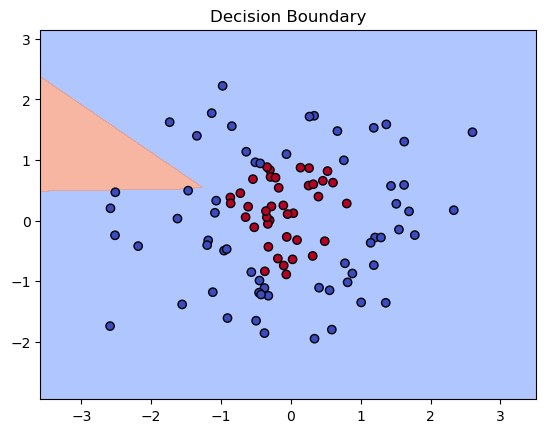

In [11]:
# 可视化决策边界
def plot_decision_boundary(model, data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    xx, yy = torch.meshgrid(torch.arange(x_min, x_max, 0.1), torch.arange(y_min, y_max, 0.1), indexing='ij')
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)
    predictions = model(grid).detach().numpy().reshape(xx.shape)
    plt.contourf(xx, yy, predictions, levels=[0, 0.5, 1], cmap='coolwarm', alpha=0.7)
    plt.scatter(data[:, 0], data[:, 1], c=labels.squeeze(), cmap='coolwarm', edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(model, data)

# 数据处理与加载

## torch.utils.data.Dataset
`torch.utils.data.Dataset` 是一个抽象类，允许你从自己的数据源中创建数据集。

需要继承该类并实现以下两个方法：

- `__len__(self)`：返回数据集中的样本数量。
- `__getitem__(self, idx)`：通过索引返回一个样本。

In [14]:
import torch
from torch.utils.data import Dataset

# 自定义数据集类
class MyDataset(Dataset):
    def __init__(self, X_data, Y_data):
        """
        初始化数据集，X_data 和 Y_data 是两个列表或数组
        X_data: 输入特征
        Y_data: 目标标签
        """
        self.X_data = X_data
        self.Y_data = Y_data

    def __len__(self):
        """返回数据集的大小"""
        return len(self.X_data)

    def __getitem__(self, idx):
        """返回指定索引的数据"""
        x = torch.tensor(self.X_data[idx], dtype=torch.float32)  # 转换为 Tensor
        y = torch.tensor(self.Y_data[idx], dtype=torch.float32)
        return x, y

# 示例数据
X_data = [[1, 2], [3, 4], [5, 6], [7, 8]]  # 输入特征
Y_data = [1, 0, 1, 0]  # 目标标签

# 创建数据集实例
dataset = MyDataset(X_data, Y_data)

## torch.utils.data.Dataloader
DataLoader 允许我们批量读取数据并进行多线程加载，从而提高训练效率。

In [15]:
from torch.utils.data import DataLoader

# 创建 DataLoader 实例，batch_size 设置每次加载的样本数量
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
'''
batch_size: 每次加载的样本数量。
shuffle: 是否对数据进行洗牌，通常训练时需要将数据打乱。
drop_last: 如果数据集中的样本数不能被 batch_size 整除，设置为 True 时，丢弃最后一个不完整的 batch。

'''
# 打印加载的数据
for epoch in range(1):
    for batch_idx, (inputs, labels) in enumerate(dataloader):
        print(f'Batch {batch_idx + 1}:')
        print(f'Inputs: {inputs}')
        print(f'Labels: {labels}')

Batch 1:
Inputs: tensor([[7., 8.],
        [3., 4.]])
Labels: tensor([0., 0.])
Batch 2:
Inputs: tensor([[1., 2.],
        [5., 6.]])
Labels: tensor([1., 1.])


## torch.utils.data.TenserDataset
基于张量的数据集，适合处理数据-标签对，直接支持批处理和迭代。

## torchvision.transforms
PyTorch 提供了 torchvision.transforms 模块来进行常见的图像预处理和增强操作，如旋转、裁剪、归一化等。

In [ ]:
from torchvision import transforms
from PIL import Image

# 定义数据预处理的流水线
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # 随机水平翻转
    transforms.RandomRotation(30),  # 随机旋转 30 度
    transforms.RandomResizedCrop(128),  # 随机裁剪并调整为 128x128
    transforms.ToTensor(), # 将图像转换为张量
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 三个通道分别标准化
])

image = Image.open('image.jpg')
image_tensor = transform(image)


## trochvision.datasets
orchvision.datasets 提供了许多常见数据集以及用于加载图像数据的工具。

常用数据集：
- MNIST：手写数字图像数据集，用于图像分类任务。
- CIFAR：包含 10 个类别、60000 张 32x32 的彩色图像数据集，用于图像分类任务。
- COCO：通用物体检测、分割、关键点检测数据集，包含超过 330k 个图像和 2.5M 个目标实例的大规模数据集。
- ImageNet：包含超过 1400 万张图像，用于图像分类和物体检测等任务。
- STL-10：包含 100k 张 96x96 的彩色图像数据集，用于图像分类任务。
- Cityscapes：包含 5000 张精细注释的城市街道场景图像，用于语义分割任务。
- SQUAD：用于机器阅读理解任务的数据集。

In [ ]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# 定义预处理操作
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 对灰度图像进行标准化
])

# 下载并加载 MNIST 数据集
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
'''
datasets.MNIST() 会自动下载 MNIST 数据集并加载。
transform 参数允许我们对数据进行预处理。
train=True 和 train=False 分别表示训练集和测试集。
'''

# 创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 迭代训练数据
for inputs, labels in train_loader:
    print(inputs.shape)  # 每个批次的输入数据形状
    print(labels.shape)  # 每个批次的标签形状

## torchvision.datasets.ImageFolder
从文件夹加载图像数据，每个子文件夹代表一个类别，适用于图像分类任务。

## torchtext
自然语言处理工具包，提供了文本数据处理和建模的工具，包括数据预处理和数据加载的方式。

## 合并数据集
PyTorch 提供了 ConcatDataset 和 ChainDataset 等类来连接多个数据集。

>```py
>from torch.utils.data import ConcatDataset
>
># 假设 dataset1 和 dataset2 是两个 Dataset 对象
>combined_dataset = ConcatDataset([dataset1, dataset2])
>combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=True)

# 线性回归

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 随机种子，确保每次运行结果一致
torch.manual_seed(42)

# 生成训练数据
X = torch.randn(100, 2)  # 100 个样本，每个样本 2 个特征
true_w = torch.tensor([2.0, 3.0])  # 假设真实权重
true_b = torch.tensor(4.0)  # 偏置项
Y = X @ true_w + true_b + torch.randn(100) * 0.1  # 加入一些噪声

# 打印部分数据
print(X[:5])
print(Y[:5])

tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487]])
tensor([12.4460, -0.4663,  1.7666, -0.9357,  7.4781])


In [20]:
from torch import nn

# 定义线性回归模型
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 定义一个线性层，输入为2个特征，输出为1个预测值
        self.linear = nn.Linear(2, 1)  # 输入维度2，输出维度1
    
    def forward(self, x):
        return self.linear(x)  # 前向传播，返回预测结果

# 创建模型实例
model = LinearRegressionModel()

In [ ]:
from torch import optim

# 损失函数（均方误差）
criterion = nn.MSELoss()

# 优化器（使用 SGD 或 Adam）
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 学习率设置为0.01

In [22]:
# 训练模型
epochs = 1000  # 训练 1000 轮
for epoch in range(epochs):
    model.train()  # 设置模型为训练模式

    # 前向传播
    predictions = model(X)  # 模型输出预测值
    loss = criterion(predictions.squeeze(), Y)  # 计算损失
    # 注意：predictions 的形状是 (3, 1)，而 Y 的形状是 (3,)。所以预测值需要压缩为1D
    # .squeeze()移除张量中大小为 1 的维度

    # 反向传播
    optimizer.zero_grad()  # 清空之前的梯度
    loss.backward()  # 计算梯度
    optimizer.step()  # 更新模型参数

    # 打印损失
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/1000], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.4569
Epoch [200/1000], Loss: 0.0142
Epoch [300/1000], Loss: 0.0082
Epoch [400/1000], Loss: 0.0081
Epoch [500/1000], Loss: 0.0081
Epoch [600/1000], Loss: 0.0081
Epoch [700/1000], Loss: 0.0081
Epoch [800/1000], Loss: 0.0081
Epoch [900/1000], Loss: 0.0081
Epoch [1000/1000], Loss: 0.0081


Predicted weight: [[2.009702  2.9986038]]
Predicted bias: [4.020908]


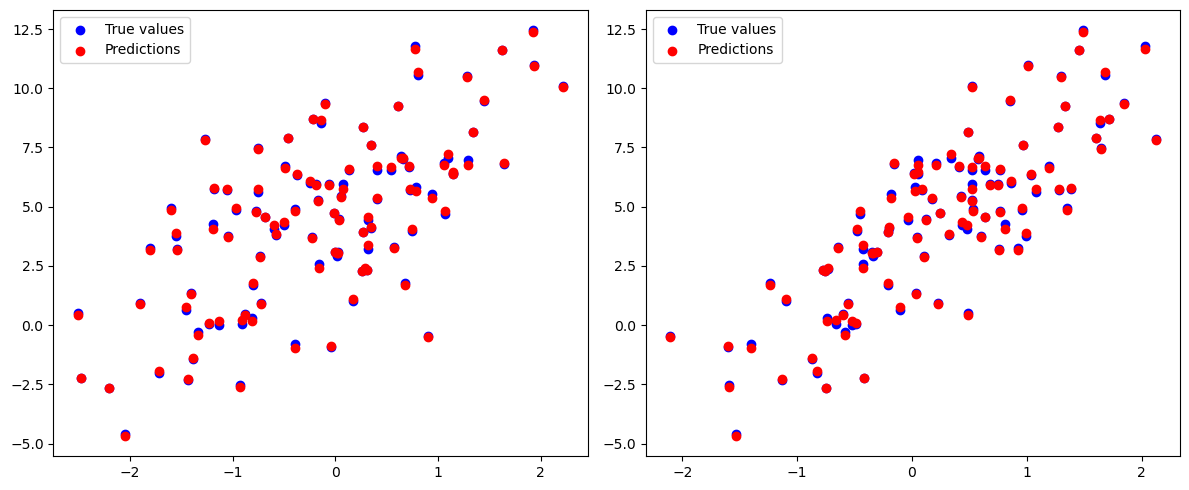

In [ ]:
# 查看训练后的权重和偏置
print(f'Predicted weight: {model.linear.weight.data.numpy()}') # 模型的输出权重应该接近 true_w 和 true_b
print(f'Predicted bias: {model.linear.bias.data.numpy()}') 

# 在新数据上做预测
with torch.no_grad():  # 评估时不需要计算梯度
    predictions = model(X)

# 可视化预测与实际值
# 绘制第一个特征的散点图
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], Y, color='blue', label='True values')
plt.scatter(X[:, 0], predictions, color='red', label='Predictions')
plt.legend()

# 绘制第二个特征的散点图
plt.subplot(1, 2, 2)
plt.scatter(X[:, 1], Y, color='blue', label='True values')
plt.scatter(X[:, 1], predictions, color='red', label='Predictions')
plt.legend()

plt.tight_layout()
plt.show()
# 在可视化的散点图中，蓝色点表示真实值，红色点表示模型的预测值。我们希望看到红色点与蓝色点尽可能接近，表明模型成功学习了数据的线性关系。

# 卷积神经网络

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from matplotlib import pyplot as plt

# 1.数据加载与预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 转为张量
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [ ]:
# 2.模型定义
# MNIST输入张量的形状 (batch_size, 1, 28, 28)  # (N, C, H, W)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # ========== 卷积层部分 ==========
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        
        # ========== 激活函数（ReLU） ==========
        self.relu = nn.ReLU()
        
        # ========== 池化层（MaxPool2d） ==========
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 2x2最大池化
        
        # ========== 全连接层部分 ==========
        self.fc1 = nn.Linear(in_features=64 * 7 * 7, out_features=128) # 输入大小 = 通道数 * 特征图大小
        self.fc2 = nn.Linear(in_features=128, out_features=10) # 10 个类别

    def forward(self, x):
        # ========== 第一层卷积 + ReLU + 池化 ==========
        x = self.conv1(x)          # 卷积计算 (64, 1, 28, 28) -> (64, 32, 28, 28)
        x = self.relu(x)           # ReLU激活 
        x = self.pool(x)           # 最大池化 (64, 32, 28, 28) -> (64, 32, 14, 14)
        
        # ========== 第二层卷积 + ReLU + 池化 ==========
        x = self.conv2(x)          # 卷积计算 (64, 32, 14, 14) -> (64, 64, 14,14)
        x = self.relu(x)           # ReLU激活
        x = self.pool(x)           # 最大池化 (64, 64, 14,14) -> (64, 64, 7, 7)
        
        # ========== 展平 + 全连接层 ==========
        x = x.view(-1, 64 * 7 * 7) # 展平操作 (64, 64, 7, 7) -> (64, 64 * 7 * 7) (-1表示自动计算batch大小)
        x = self.fc1(x)            # 全连接层1 (64, 64 * 7 * 7) -> (64, 128)
        x = self.relu(x)           # ReLU激活
        x = self.fc2(x)            # 全连接层2 (64, 128) -> (64,10)
        
        return x

model = SimpleCNN()

In [ ]:
# 3.损失函数与优化器定义
criterion = nn.CrossEntropyLoss()  # 多分类交叉熵损失
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # 学习率和动量

In [ ]:
# 4.模型训练
epochs = 5

for epoch in range(epochs):
    model.train() # 训练模式（启用 Dropout、BatchNorm 的动态统计）
    total_loss = 0 # 将所有批次的损失值相加，得到整个 epoch 的总损失。

    for images,labels in train_loader:
        predictions = model(images)
        loss = criterion(predictions,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}") # 计算整个 epoch 的平均损失


Epoch [1/5], Loss: 0.2393
Epoch [2/5], Loss: 0.0532
Epoch [3/5], Loss: 0.0365
Epoch [4/5], Loss: 0.0278
Epoch [5/5], Loss: 0.0219


In [39]:
# 5.模型测试
model.eval()  # 设置为评估模式（固定 Dropout、使用训练时计算的 BatchNorm 均值和方差）。
correct = 0
total = 0

with torch.no_grad():  # 评估时不需要计算梯度
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  # 沿维度 1（即类别维度）取最大值。_：最大值（logits 中的最高分，这里不需要）。predicted：最大值对应的索引（即预测的类别标签）。
        total += labels.size(0) # 累计总样本数
        correct += (predicted == labels).sum().item() # .item()：将单元素张量转换为 Python 标量

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.72%


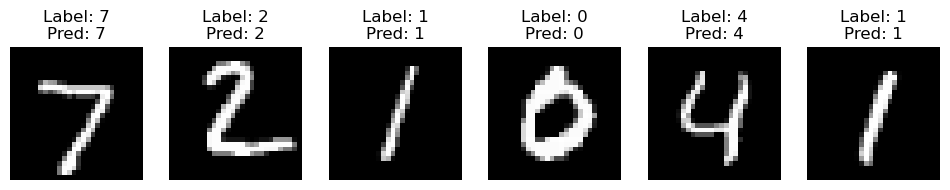

In [ ]:
# 6.可视化
dataiter = iter(test_loader) # 创建测试集的迭代器
images, labels = next(dataiter) # 获取第一个批次的数据
outputs = model(images) # 前向传播，得到模型输出
_, predictions = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 6, figsize=(12, 4))
for i in range(6):
    axes[i].imshow(images[i][0], cmap='gray')
    axes[i].set_title(f"Label: {labels[i]}\nPred: {predictions[i]}")
    axes[i].axis('off')
plt.show()

# 循环神经网络
专门用于处理序列数据，能够捕捉时间序列或有序数据的动态信息，能够处理序列数据，如文本、时间序列或音频。

PyTorch 提供了几种 RNN 模块，包括：
- torch.nn.RNN：基本的RNN单元。
- torch.nn.LSTM：长短期记忆单元，能够学习长期依赖关系。
- torch.nn.GRU：门控循环单元，是LSTM的简化版本，但通常更容易训练。

使用 RNN 类时，您需要指定输入的维度、隐藏层的维度以及其他一些超参数。
>```py
>torch.nn.RNN(
>    input_size,             # 输入特征的维度
>    hidden_size,            # 隐藏状态的维度
>    num_layers=1,           # RNN 堆叠的层数（默认1层）
>    nonlinearity='tanh',    # 激活函数（'tanh' 或 'relu'）
>    bias=True,              # 是否使用偏置项
>    batch_first=False,      # 输入数据的形状格式（默认False）
>    dropout=0,              # 层间Dropout概率（仅当num_layers>1时生效）
>    bidirectional=False     # 是否为双向RNN
>)

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from torch import optim

# 1.数据准备与处理
num_samples = 1000 # 1000个样本
seq_len = 10       # 每个样本是10个时间步
input_size = 5     # 每个时间步有5个特征值
output_size = 2    # 分类任务的类别数（二分类问题），标签为0或1。

X = torch.randn(num_samples,seq_len,input_size) # (batch_size, seq_len, input_size)
Y = torch.randint(0,output_size,(num_samples,)) # (batch_size, output_size)

dataset = TensorDataset(X,Y)
train_loader = DataLoader(dataset,batch_size=64,shuffle=True)

In [4]:
# 2.模型定义
class SimpleRNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 定义 RNN 层
        self.RNN = nn.RNN(input_size=5,hidden_size=64,batch_first=True) 
        # batch_first=True：(batch_size, seq_len, input_size) 
        # batch_first=False：(seq_len, batch_size, input_size)
        
        # 定义全连接层
        self.Linear = nn.Linear(64,2)

    def forward(self,x):
        # x: (batch_size, seq_len, input_size)
        x , _ = self.RNN(x) # x: (batch_size, seq_len, hidden_size)
        x =  x[:,-1,:]      # 取序列最后一个时间步的输出作为模型的输出 x: (batch_size, hidden_size)
        x = self.Linear(x)
        return x

model = SimpleRNN()

In [5]:
# 3.损失函数与优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [ ]:
# 4.训练模型
for epoch in range(10):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs,labels in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # 计算准确率
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{10}], Loss: {total_loss / len(train_loader):.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 0.6825, Accuracy: 57.40%
Epoch [2/10], Loss: 0.6812, Accuracy: 54.90%
Epoch [3/10], Loss: 0.6812, Accuracy: 56.10%
Epoch [4/10], Loss: 0.6805, Accuracy: 56.30%
Epoch [5/10], Loss: 0.6802, Accuracy: 54.80%
Epoch [6/10], Loss: 0.6801, Accuracy: 55.60%
Epoch [7/10], Loss: 0.6800, Accuracy: 55.30%
Epoch [8/10], Loss: 0.6786, Accuracy: 56.30%
Epoch [9/10], Loss: 0.6794, Accuracy: 56.40%
Epoch [10/10], Loss: 0.6776, Accuracy: 55.60%


In [10]:
# 5.测试模型
model.eval()  # 设置模型为评估模式
with torch.no_grad():
    total = 0
    correct = 0
    for inputs, labels in train_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 57.00%


实例：字符预测

Epoch [20/200], Loss: 0.0020
Epoch [40/200], Loss: 0.0002
Epoch [60/200], Loss: 0.0001
Epoch [80/200], Loss: 0.0001
Epoch [100/200], Loss: 0.0001
Epoch [120/200], Loss: 0.0001
Epoch [140/200], Loss: 0.0001
Epoch [160/200], Loss: 0.0001
Epoch [180/200], Loss: 0.0001
Epoch [200/200], Loss: 0.0001
Input sequence:  hello
Predicted sequence:  elloh


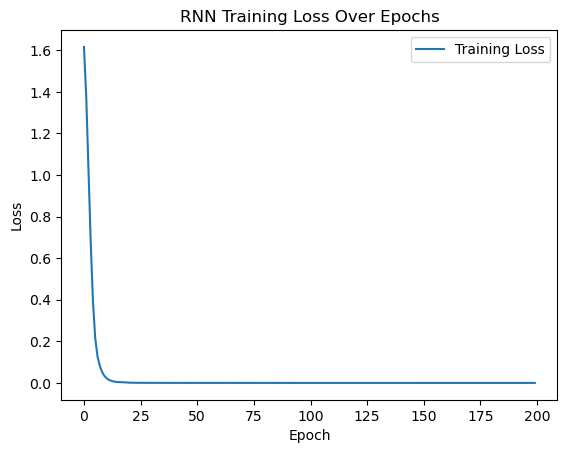

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 数据集：字符序列预测（Hello -> Elloh）
char_set = list("hello") # ['h', 'e', 'l', 'l', 'o']
char_to_idx = {c: i for i, c in enumerate(char_set)} # {'h':0, 'e':1, 'l':2, 'o':3}
idx_to_char = {i: c for i, c in enumerate(char_set)} # {0:'h', 1:'e', 2:'l', 3:'o'}

# 数据准备
input_str = "hello"
target_str = "elloh"
input_data = [char_to_idx[c] for c in input_str] # [0, 1, 2, 2, 3]
target_data = [char_to_idx[c] for c in target_str] # [1, 2, 2, 3, 0]

# 转换为独热编码
input_one_hot = np.eye(len(char_set))[input_data] # 生成一个 5×5 的单位矩阵。[input_data]：用 input_data 的索引选取行，得到 5×4 的独热编码矩阵。
# [0] → [1,0,0,0,0]
# [1] → [0,1,0,0,0]
# [2] → [0,0,1,0,0]
# [2] → [0,0,1,0,0]
# [3] → [0,0,0,1,0]

# 转换为 PyTorch Tensor
inputs = torch.tensor(input_one_hot, dtype=torch.float32)
targets = torch.tensor(target_data, dtype=torch.long)

# 模型超参数
input_size = len(char_set)
hidden_size = 8
output_size = len(char_set)
num_epochs = 200
learning_rate = 0.1

# 定义 RNN 模型
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)  # 应用全连接层
        return out, hidden

model = RNNModel(input_size, hidden_size, output_size)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 训练 RNN
losses = []
hidden = None  # 初始隐藏状态为 None
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # 前向传播
    outputs, hidden = model(inputs.unsqueeze(0), hidden)
    hidden = hidden.detach()  # 防止梯度爆炸

    # 计算损失
    loss = criterion(outputs.view(-1, output_size), targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

# 测试 RNN
with torch.no_grad():
    test_hidden = None
    test_output, _ = model(inputs.unsqueeze(0), test_hidden)
    predicted = torch.argmax(test_output, dim=2).squeeze().numpy()

    print("Input sequence: ", ''.join([idx_to_char[i] for i in input_data]))
    print("Predicted sequence: ", ''.join([idx_to_char[i] for i in predicted]))

# 可视化损失
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Loss Over Epochs")
plt.legend()
plt.show()

# Transformer
在 Transformer 模型出现之前，NLP 领域的主流模型是基于 RNN 的架构，如 LSTM 和 GRU。这些模型通过顺序处理输入数据来捕捉序列中的依赖关系，但存在以下问题：

- 梯度消失问题：长距离依赖关系难以捕捉。
- 顺序计算的局限性：无法充分利用现代硬件的并行计算能力，训练效率低下。

Transformer 通过引入自注意力机制解决了这些问题，允许模型同时处理整个输入序列，并动态地为序列中的每个位置分配不同的权重。

![image-2.png](../images/Transformer.png)

>```mermaid
>flowchart TD
>    A[输入序列] --> B[编码器]
>    B -->|自注意力| C[多头自注意力]
>    B -->|前馈网络| D[前馈网络]
>    B --> E[解码器]
>    E -->|自注意力| F[多头自注意力]
>    E -->|编码器-解码器注意力| G[编码器-解码器注意力]
>    E -->|前馈网络| H[前馈网络]
>    E --> I[输出序列]
>```    
>**编码器（Encoder）**
>
>由 NN 层相同的模块堆叠而成，每层包含两个子层：
>
>- 多头自注意力机制（Multi-Head Self-Attention）：计算输入序列中每个词与其他词的相关性。
>- 前馈神经网络（Feed-Forward Neural Network）：对每个词进行独立的非线性变换。
>
>每个子层后面都接有 残差连接（Residual Connection） 和 层归一化（Layer Normalization）。
>
>**解码器（Decoder）**
>也由 NN 层相同的模块堆叠而成，每层包含三个子层：
>- 掩码多头自注意力机制（Masked Multi-Head Self-Attention）：计算输出序列中每个词与前面词的相关性（使用掩码防止未来信息泄露）。
>- 编码器-解码器注意力机制（Encoder-Decoder Attention）：计算输出序列与输入序列的相关性。
>- 前馈神经网络（Feed-Forward Neural Network）：对每个词进行独立的非线性变换。


## 自注意力机制（Self-Attention）
自注意力机制允许模型在处理序列时，动态地为每个位置分配不同的权重，从而捕捉序列中任意两个位置之间的依赖关系。

- 输入表示：输入序列中的每个词通过词嵌入（Embedding）转换为向量表示。
- 注意力权重计算：通过计算查询（Query）、键（Key）和值（Value）之间的点积，得到每个词与其他词的相关性权重。
- 加权求和：使用注意力权重对值（Value）进行加权求和，得到每个词的上下文表示。

$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right) V
$$

${d_k}$ 是向量的维度，用于缩放点积，防止梯度爆炸。

## 多头注意力（Multi-Head Attention）
将输入分成多个子空间，每个子空间独立计算注意力，最后将结果拼接起来。

- 允许模型关注序列中不同的部分，例如语法结构、语义关系等。
- 多个注意力头可以并行计算，提高效率。

## 位置编码（Positional Encoding）
Transformer 没有显式的序列信息（如 RNN 中的时间步），位置编码被用来为输入序列中的每个词添加位置信息。通常使用正弦和余弦函数生成位置编码：
$$
\begin{cases}
PE_{(pos, 2i)} = \sin\left( \dfrac{pos}{10000^{2i/d_{\text{model}}}} \right) \\
PE_{(pos, 2i+1)} = \cos\left( \dfrac{pos}{10000^{2i/d_{\text{model}}}} \right)
\end{cases}
$$
pos 是词的位置，i 是维度索引。

## 残差连接和层归一化
为了稳定训练过程，每个子层（如自注意力层和前馈神经网络）后面都会接一个残差连接和层归一化（Layer Normalization）。

## 简单实现

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleTransformer(nn.Module):
    def __init__(self, input_dim, model_dim, num_heads, num_layers, output_dim):
        super().__init__()
        # 词嵌入层
        self.embedding = nn.Embedding(input_dim, model_dim)
        # 位置编码：告诉模型单词的顺序
        self.positional_encoding = nn.Parameter(torch.zeros(1, 1000, model_dim))  # [1, 最大序列长度, 向量维度] 假设序列长度最大为1000 
        self.transformer = nn.Transformer(
            d_model=model_dim, 
            nhead=num_heads,
            num_encoder_layers=num_layers
        )
        self.fc = nn.Linear(model_dim, output_dim)

    def forward(self, src, tgt):
        # 获取序列长度
        src_seq_length, tgt_seq_length = src.size(1), tgt.size(1)
        # 嵌入 + 位置编码
        src = self.embedding(src) + self.positional_encoding[:, :src_seq_length, :] # 从长度 1000 的位置编码里，只截取 当前句子实际长度 的部分！
        tgt = self.embedding(tgt) + self.positional_encoding[:, :tgt_seq_length, :]
        transformer_output = self.transformer(src, tgt)
        output = self.fc(transformer_output)
        return output

# 超参数
input_dim = 10000  # 词汇表大小
model_dim = 512    # 模型维度
num_heads = 8      # 多头注意力头数
num_layers = 6     # 编码器和解码器层数
output_dim = 10000 # 输出维度（通常与词汇表大小相同）

# 初始化模型、损失函数和优化器
model = SimpleTransformer(input_dim, model_dim, num_heads, num_layers, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 假设输入数据
src = torch.randint(0, input_dim, (10, 32))  # (序列长度, 批量大小)
tgt = torch.randint(0, input_dim, (20, 32))  # src 进 Encoder , tgt 进 Decoder

# 前向传播
output = model(src, tgt) # 输出形状：[序列长度, batch大小, 词汇表大小]

# 计算损失
loss = criterion(output.view(-1, output_dim), tgt.view(-1))

# 反向传播和优化
optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Loss:", loss.item())

d:\Miniconda3\envs\pytorch_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Loss: 9.383490562438965


# Transformer Pytorch 实现

In [ ]:
import torch
from torch import nn
from torch import optim
from torch.utils import data
import math
import copy



# optim 优化器模块
| 优化器名称 | 主要特点 | 适用场景 |
| :--: | :--: | :--: |
| SGD | 简单基础 | 基础教学、简单模型 |
| Adam | 自适应学习率 | 大多数深度学习任务 |
| RMSprop | 适应学习率 | RNN网络 |
| Adagrad | 参数独立学习率 | 稀疏数据 |

- state_dict()：获取优化器状态（可用于保存和加载）
- load_state_dict()：加载优化器状态

>```mermaid
>flowchart TD
>    A[选择优化器] --> B{数据是否稀疏}
>    B -->|是| C[考虑Adagrad]
>    B -->|否| D{需要快速收敛}
>    D -->|是| E[选择Adam或RMSprop]
>    D -->|否| F[使用SGD+动量]
>    
>    %% 样式还原原图的浅绿色填充
>    classDef startend fill:#d9f2d9,stroke:#333,stroke-width:1px,color:#000
>    classDef decision fill:#d9f2d9,stroke:#333,stroke-width:1px,color:#000
>    classDef process fill:#d9f2d9,stroke:#333,stroke-width:1px,color:#000
>    
>    class A startend
>    class B,D decision
>    class C,E,F process

## SGD
>```py
>optim.SGD(model.parameters(), lr=0.01, momentum=0, dampening=0, 
>          weight_decay=0, nesterov=False)
>```
| 参数名 | 含义 | 默认值 | 说明与常用值 |
|--------|------|--------|--------------|
| `params` | 待优化参数 | — | 必须传入，一般写 `model.parameters()`，指定要更新的模型权重 |
| `lr` | 学习率 | `0.01` | 控制参数更新步长，最重要超参；常用 `0.1, 0.01, 0.001` |
| `momentum` | 动量 | `0` | 累积历史梯度，加速收敛、抑制震荡；常用 `0.9, 0.95` |
| `dampening` | 动量阻尼 | `0` | 对动量项的抑制系数，仅普通动量生效，一般保持默认 |
| `weight_decay` | 权重衰减 | `0` | 等价于 L2 正则化，防止过拟合；常用 `1e-4, 1e-5` |
| `nesterov` | Nesterov 动量 | `False` | 是否开启 Nesterov 加速梯度，收敛更稳定，可设为 `True` |
| `maximize` | 最大化目标 | `False` | 是否最大化损失/指标，默认最小化损失 |
| `foreach` | 快速实现 | `None` | 是否使用更快的底层实现，一般不用改 |
| `differentiable` | 可微 | `False` | 用于梯度嵌套优化等特殊场景，普通训练不用动 |

## Adam
>```py
>optim.Adam(params, lr=0.001, betas=(0.9, 0.999), 
>           eps=1e-08, weight_decay=0, amsgrad=False)
>```           
>| 参数名 |  含义 | 默认值 | 说明 |
>|--------|-----------|--------|----------------|
>| `betas` | 动量衰减系数 | `(0.9, 0.999)` | 两个值：<br>• `beta1`：一阶矩（梯度）衰减率<br>• `beta2`：二阶矩（梯度平方）衰减率<br>几乎不用改 |
>| `eps` | 平滑小常数 | `1e-8` | 防止分母为 0，保证数值稳定；**不用改** |
>| `weight_decay` | 权重衰减 | `0` | L2 正则化，防止过拟合；常用 `1e-4`、`1e-5` |
>| `amsgrad` | 是否使用 AMSGrad 变体 | `False` | 改进版 Adam，默认关闭；训练不收敛时可尝试打开 |

## 高级技巧
学习率调度
>```py
>from torch import optim
>from torch.optim.lr_scheduler import StepLR
>
>optimizer = optim.Adam(model.parameters(),lr=0.01)
>scheduler = StepLR(optimizer,step_size=10,gamma=0.1) # StepLR = 每隔 N 个 epoch，学习率 × gamma
>
>for epoch in range(100):  # 训练 100 轮
>    train(...)       # 训练
>    validate(...)    # 验证
>    scheduler.step() # 每轮结束后更新学习率
>```

参数分组优化
>```py
>optim.SGD([
>    {'params':model.base.pararmeters()},
>    {'params':model.classifier.parameters(),lr=0.01}
>],lr=0.001) # # 全局默认学习率
>```

梯度裁剪
>```py
>loss.backward()                # 1. 计算梯度
>torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 2. 裁剪梯度 注意：放在反向传播之后、优化器更新之前
>optimizer.step()               # 3. 更新参数 
>```

# torchvision 模块
- 预训练模型：包含经典的 CNN 架构实现（如 ResNet、VGG、AlexNet 等）
- 数据集工具：内置常用视觉数据集（如 CIFAR10、MNIST、ImageNet 等）
- 图像变换：提供各种图像预处理和数据增强方法
- 实用工具：包括视频处理、图像操作等辅助功能

## torchvision.models

| 模型类型 | 模型名称 | 特点 |
|---------|---------|------|
| ResNet | resnet18/34/50 | 通用最强 |
| VGG | vgg16/19 | 经典稳定 |
| MobileNet | mobilenet_v2/v3 | 轻量、手机端 |
| EfficientNet | efficientnet_b0~b7 | 精度高 |
| ViT | vit_b_16 | Transformer 图像模型 |
| DenseNet | densenet121 | 特征复用 |
>```py
>import torchvision.models as models
>
># 加载预训练模型
>resnet18 = models.resnet18(pretrained=True)
>alexnet = models.alexnet(pretrained=True)
>vgg16 = models.vgg16(pretrained=True)
>
># 修改最后一层（适应 CIFAR10 的 10 分类）
>num_ftrs = resnet18.fc.in_features
>resnet18.fc = nn.Linear(num_ftrs, 10)

## torchvision.datasets
>```mermaid
>graph TD
>    A[torchvision.datasets] --> B[分类数据集]
>    A --> C[检测数据集]
>    A --> D[分割数据集]
>    B --> B1[CIFAR10/100]
>    B --> B2[MNIST/FashionMNIST]
>    B --> B3[ImageNet]
>    C --> C1[COCO]
>    C --> C2[VOC]
>    D --> D1[Cityscapes]

## torchvision.transforms
### 基础转换（最常用）
| 方法 | 功能 | 说明 |
|------|------|------|
| `ToTensor()` | 转张量 | 将 PIL Image / numpy 转为 `[0,1]` 的 torch 张量 |
| `ToPILImage()` | 转回图片 | 将张量转回 PIL 图像 |
| `Normalize(mean, std)` | 归一化 | 对张量做标准化，常用 `mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]` |

### 尺寸/形状变换
| 方法 | 功能 | 说明 |
|------|------|------|
| `Resize(size)` | 调整大小 | 统一缩放到指定尺寸，如 `Resize(224)` |
| `CenterCrop(size)` | 中心裁剪 | 从图片中心裁剪指定大小 |
| `RandomCrop(size)` | 随机裁剪 | 随机位置裁剪 |
| `RandomResizedCrop(size)` | 随机裁剪+缩放 | ImageNet 标准预处理 |

### 数据增强（训练用）
| 方法 | 功能 | 说明 |
|------|------|------|
| `RandomHorizontalFlip(p=0.5)` | 随机水平翻转 | 默认 50% 概率翻转 |
| `RandomVerticalFlip(p=0.5)` | 随机垂直翻转 | |
| `RandomRotation(degrees)` | 随机旋转 | 如 `RandomRotation(15)` 表示 ±15° |
| `ColorJitter()` | 颜色抖动 | 亮度、对比度、饱和度、色相随机调整 |
| `Grayscale(num_output_channels=1)` | 转灰度图 | |

### 组合/管道工具
| 方法 | 功能 | 用法示例 |
|------|------|----------|
| `Compose(transforms_list)` | 组合变换 | 把多个预处理串起来使用 |
| `RandomApply(transforms, p=0.5)` | 随机应用一组变换 | |
| `RandomChoice(transforms)` | 随机选一个变换 | |

最常用标准模板
>```python
>transform = transforms.Compose([
>    transforms.Resize(256),
>    transforms.CenterCrop(224),
>    transforms.ToTensor(),
>    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
>                         std=[0.229, 0.224, 0.225])
>])
>```

# 模型部署
>```mermaid
>flowchart TD
>    A[训练模型] --> B[模型优化]
>    B --> C[格式转换]
>    C --> D[部署环境选择]
>    D --> E[服务封装]
>    E --> F[性能监控]
>    
>    %% 还原原图浅绿色填充+绿色边框样式
>    classDef box fill:#d9f2d9,stroke:#008000,stroke-width:1px,color:#000
>    class A,B,C,D,E,F box
>```    

PyTorch 主要支持以下导出格式

| 格式 | 特点 | 适用场景 |
|------|------|----------|
| **TorchScript** | PyTorch 原生格式，保持动态图特性，无需 Python 环境即可运行 | PyTorch 生态内部使用、C++ 部署 |
| **ONNX** | 开放标准格式，跨框架兼容（支持 TensorFlow、Caffe、TensorRT 等） | 多框架协作、跨平台部署、通用推理 |
| **Torch-TensorRT** | NVIDIA 针对 GPU 优化的格式，推理速度大幅提升 | NVIDIA GPU 上高性能推理加速 |

## TorchScript
注意：
- torch.jit.trace 更适合没有控制流的模型
- torch.jit.script 能处理包含条件判断等复杂逻辑的模型
- 导出前务必调用 model.eval()

In [ ]:
import torch
import torchvision

# 加载预训练模型
model = torchvision.models.resnet18(pretrained=True)
model.eval() # 必须切换到评估模式！

# 示例输入
example_input = torch.rand(1, 3, 224, 224)

# 方法1: 通过追踪(tracing)导出
traced_model = torch.jit.trace(model, example_input)
traced_model.save("resnet18_traced.pt")

# 方法2: 通过脚本(scripting)导出
scripted_model = torch.jit.script(model)
scripted_model.save("resnet18_scripted.pt")
# 加载TorchScript模型
loaded_script = torch.jit.load('model_scripted.pt')

In [ ]:
loaded_model = torch.jit.load("resnet18_traced.pt")
loaded_model.eval()

# 推理
input = torch.randn(1,3,224,224)
output = loaded_model(input)

## ONNX

In [ ]:
model.eval()

example_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    example_input,
    "model.onnx",
    opset_version=12,           # ONNX 算子版本
    do_constant_folding=True,   # 常量折叠优化
    input_names=["input"],      # 输入节点名字（部署时要用）
    output_names=["output"]     # 输出节点名字
)

In [ ]:
import onnxruntime as ort

# 创建推理会话
ort_session = ort.InferenceSession("model.onnx")
# 准备输入
input = np.random.randn(1,3,224,224).astype(np.float32)
# 执行推理
output = ort_session.run(
    ["output"],
    {"input": input}
)

## Torch-TensorRT

In [ ]:
import torch_tensorrt

model.eval()
trt_model = torch_tensorrt.compile(
    model,
    inputs=[torch_tensorrt.Input((1, 3, 224, 224))],
    enabled_precisions={torch.float16}
)
torch.jit.save(trt_model, "model_trt.pt")

## TorchServe云端部署
PyTorch 官方专门用来做模型部署的工具
- 一键打包模型
- 自动生成 REST API
- 自带负载均衡、批处理、健康检查
- 适合生产环境、云端大规模部署

>```bash
># 安装
>pip install torchserve torch-model-archiver
>
># 打包模型
>torch-model-archiver --model-name resnet18 \
>                     --version 1.0 \
>                     --serialized-file model.pth \
>                     --extra-files index_to_name.json \
>                     --handler image_classifier \
>                     --export-path model_store
>
># 启动服务
>torchserve --start  \
>           --model-store model_store \
>           --models resnet18=resnet18.mar
>```
| 参数 | 含义 |
|-----|------|
| `--model-name` | 模型名字 |
| `--version` | 版本号 |
| `--serialized-file` | 你的模型文件（.pt / .pth） |
| `--extra-files` | 额外需要的文件（类别名等） |
| `--handler` | 处理类型（图像分类、文本等） |
| `--export-path` | 输出打包后的文件 |

输出：resnet18.mar（可直接部署的模型包）

| 参数 | 含义 |
|-----|------|
| `--start` | 启动 |
| `--model-store` | 指定模型存放的文件夹 |
| `--models` | --models  服务名称=模型文件名.mar |
| `--port 8080` | 指定端口 |
| `--ts-config config.properties` | 加载配置 |
| `--workers 4` | 启动 4 个工作进程 |
| `--log-file log.log` | 日志保存 |

预测接口：http://localhost:8080/predictions/resnet18

状态检查接口：http://localhost:8081/models

## 使用FastAPI构建REST API
>```py
>from fastapi import FastAPI
>from PIL import Image
>import io
>import torch
>
>app = FastAPI()
>model = torch.jit.load("model.pt")
>
>@app.post("/predict")
>async def predict(image: UploadFile = File(...)):
>    img_data = await image.read()
>    img = Image.open(io.BytesIO(img_data))
>    # 预处理...
>    with torch.no_grad():
>        output = model(img_tensor)
>    return {"prediction": output.argmax().item()}

## 量化
模型量化 = 把 32位浮点数(float32) 权重 变成 8位整数(int8) → 模型变小、速度变快、显存变少，精度几乎不变

| 类型 | 量化内容 | 是否需要数据 | 速度 | 难度 | 适用模型 |
|------|----------|-------------|------|------|----------|
| **动态量化** | 权重 |  不需要 | 快 | 简单 | Transformer、LSTM、文本 |
| **静态量化** | 权重+激活 |  需要校准 | 极快 | 中等 | CNN、ResNet、图像 |

In [ ]:
# 动态量化(只量化权重，激活值在推理时动态量化)
quantized_model = torch.quantization.quantize_dynamic(model, {torch.nn.Linear}, dtype=torch.qint8)

# 静态量化(权重 + 激活值 都提前量化好)
model.qconfig = torch.quantization.get_default_qconfig('fbgemm') # 用 x86 最佳量化方案
torch.quantization.prepare(model, inplace=True) # 准备量化（插入观察器）
# 校准...
for data in dataloader:
    model(data)
# 转换为量化模型    
torch.quantization.convert(model, inplace=True)

| 参数 | 含义 |
|------|------|
| `model` | 要量化的模型 |
| `{torch.nn.Linear}` | **只量化 Linear 层**（CNN 一般量化 Conv） |
| `dtype=torch.qint8` | 量化成 8 位整数 |

## TensorRT加速
方案1：Torch-TensorRT

核心参数
- enabled_precisions
  - {torch.float32}：默认，精度最高、速度一般
  - {torch.float16}：推荐，精度几乎无损、速度暴涨
  - {torch.int8}：极致加速，需校准数据
- workspace_size：给 TensorRT 临时计算的显存，建议 1GB+
- shape=[-1, 3, 224, 224]：-1 表示动态 batch

In [ ]:
import torch_tensorrt

# 编译优化
trt_model = torch_tensorrt.compile(model, 
    inputs=[torch_tensorrt.Input((1, 3, 224, 224))],
    enabled_precisions={torch.float32}
)

# 保存优化后模型
torch.jit.save(trt_model, "model_trt.pt")

In [ ]:
# 完整示例
import torch
import torch_tensorrt
import torchvision.models as models

# 1. 加载模型 + 设为评估模式 + 移到 GPU
model = models.resnet50(pretrained=True).eval().cuda()

# 2. 定义输入规格（支持动态 batch：-1）
input_spec = [
    torch_tensorrt.Input(
        shape=[-1, 3, 224, 224],  # 动态 batch size
        dtype=torch.float32,
        format=torch.contiguous_format
    )
]

# 3. 编译为 TensorRT 模型
trt_model = torch_tensorrt.compile(
    model,
    inputs=input_spec,
    enabled_precisions={torch.float16},  # 启用 FP16（速度最快）
    workspace_size=1 << 30,              # 工作空间 1GB
    truncate_long_and_double=True,        # 截断 64bit 类型
)

# 4. 推理（和普通 PyTorch 一样用）
x = torch.randn(4, 3, 224, 224).cuda()  # batch=4
with torch.no_grad():
    out = trt_model(x)
print(out.shape)  # torch.Size([4, 1000])

# 5. 保存/加载（可部署）
torch.jit.save(trt_model, "resnet50_trt.ts")
loaded_trt_model = torch.jit.load("resnet50_trt.ts").cuda()

方案2：PyTorch → ONNX → TensorRT 加速

...

# 模型保存与加载

## 保存整个模型

In [ ]:
import torch
import torchvision

model = torchvision.models.resnet18(pretrained=True)
#...训练模型...

# 保存
torch.save(model,'model.pth')
# 加载
load_model = torch.load('model.pth')

## 仅保存模型参数（推荐）

In [ ]:
# 保存模型的状态字典(state_dict)：
torch.save(model.state_dict(),'model_weights.pth')

model = torchvision.models.resnet18(pretrained=True) # 必须先创建相同架构的模型
model.load_state_dict(torch.load('model_weights.pth'))
model.eval()

## 保存和加载训练状态

In [ ]:
# 保存检查点
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss,
    # 可以添加其他需要保存的信息
}

torch.save(checkpoint, 'checkpoint.pth')

# 加载检查点
checkpoint = torch.load('checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']

model.eval()  # 或 model.train()

## 跨设备加载模型

In [ ]:
torch.save(model.state_dict(), 'model_weights.pth')

# 加载到CPU（GPU->CPU）
model.load_state_dict(torch.load('model_weights.pth', map_location=torch.device('cpu')))

# 加载到GPU（CPU->GPU,GPU->GPU）
model.load_state_dict(torch.load('model_weights.pth', map_location=torch.device('cuda')))
model.to(device)

model.eval()    

In [ ]:
# 多GPU训练模型加载
model = torchvision.models.resnet18(num_classes=10)
model = nn.DataParallel(model)   # 或 DDP
model = model.cuda()

#...训练模型...

torch.save(model.module.state_dict(), 'multigpu_model.pth')

model = torchvision.models.resnet18(pretrained=True)  # 先定义普通模型
model.load_state_dict(torch.load('multigpu_model.pth'))

## 完整示例

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 定义一个简单模型
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(10, 2)
    
    def forward(self, x):
        return self.fc(x)

# 初始化
model = SimpleModel()
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 模拟训练过程
for epoch in range(5):
    # 模拟训练步骤
    inputs = torch.randn(32, 10)
    labels = torch.randint(0, 2, (32,))
    
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    
    # 每2个epoch保存一次检查点
    if epoch % 2 == 0:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss.item(),
        }
        torch.save(checkpoint, f'checkpoint_epoch{epoch}.pth')
        print(f'Checkpoint saved at epoch {epoch}')

# 最终保存
torch.save(model.state_dict(), 'final_model.pth')

# 加载示例
loaded_model = SimpleModel()
loaded_model.load_state_dict(torch.load('final_model.pth'))
loaded_model.eval()

# 测试加载的模型
test_input = torch.randn(1, 10)
with torch.no_grad():
    output = loaded_model(test_input)
print(f'Test output: {output}')

#

# 速查手册
### Tensors
| API | 描述 |
| ---- | ---- |
| is_tensor(obj) | 检查 obj 是否为 PyTorch 张量。 |
| is_storage(obj) | 检查 obj 是否为 PyTorch 存储对象。 |
| is_complex(input) | 检查 input 数据类型是否为复数数据类型。 |
| is_conj(input) | 检查 input 是否为共轭张量。 |
| is_floating_point(input) | 检查 input 数据类型是否为浮点数据类型。 |
| is_nonzero(input) | 检查 input 是否为非零单一元素张量。 |
| set_default_dtype(d) | 设置默认浮点数据类型为 d。 |
| get_default_dtype() | 获取当前默认浮点 torch.dtype。 |
| set_default_device(device) | 设置默认 torch.Tensor 分配的设备为 device。 |
| get_default_device() | 获取默认 torch.Tensor 分配的设备。 |
| numel(input) | 返回 input 张量中的元素总数。 |

### Creation Ops
| API | 描述 |
| ---- | ---- |
| tensor(data) | 通过复制 data 构造无自动梯度历史的张量。 |
| sparse_coo_tensor(indices, values) | 在指定的 indices 处构造稀疏张量，具有指定的值。 |
| as_tensor(data) | 将 data 转换为张量，共享数据并尽可能保留自动梯度历史。 |
| zeros(size) | 返回一个用标量值 0 填充的张量，形状由 size 定义。 |
| ones(size) | 返回一个用标量值 1 填充的张量，形状由 size 定义。 |
| arange(start, end, step) | 返回一个 1-D 张量，包含从 start 到 end 的值，步长为 step。 |
| rand(size) | 返回一个从 [0, 1) 区间均匀分布的随机数填充的张量。 |
| randn(size) | 返回一个从标准正态分布填充的张量。 |

### Math operations
| API | 描述 |
| ---- | ---- |
| add(input, other, alpha) | 将 other（由 alpha 缩放）加到 input 上。 |
| mul(input, other) | 将 input 与 other 相乘。 |
| matmul(input, other) | 执行 input 和 other 的矩阵乘法。 |
| mean(input, dim) | 计算 input 在维度 dim 上的均值。 |
| sum(input, dim) | 计算 input 在维度 dim 上的和。 |
| max(input, dim) | 返回 input 在维度 dim 上的最大值。 |
| min(input, dim) | 返回 input 在维度 dim 上的最小值。 |

### Tensor 创建
| 函数 | 描述 |
| ---- | ---- |
| torch.tensor(data, dtype, device, requires_grad) | 从数据创建张量。 |
| torch.as_tensor(data, dtype, device) | 将数据转换为张量（共享内存）。 |
| torch.from_numpy(ndarray) | 从 NumPy 数组创建张量（共享内存）。 |
| torch.zeros(*size, dtype, device, requires_grad) | 创建全零张量。 |
| torch.ones(*size, dtype, device, requires_grad) | 创建全一张量。 |
| torch.empty(*size, dtype, device, requires_grad) | 创建未初始化的张量。 |
| torch.arange(start, end, step, dtype, device, requires_grad) | 创建等差序列张量。 |
| torch.linspace(start, end, steps, dtype, device, requires_grad) | 创建等间隔序列张量。 |
| torch.logspace(start, end, steps, base, dtype, device, requires_grad) | 创建对数间隔序列张量。 |
| torch.eye(n, m, dtype, device, requires_grad) | 创建单位矩阵。 |
| torch.full(size, fill_value, dtype, device, requires_grad) | 创建填充指定值的张量。 |
| torch.rand(*size, dtype, device, requires_grad) | 创建均匀分布随机张量（范围 [0, 1)）。 |
| torch.randn(*size, dtype, device, requires_grad) | 创建标准正态分布随机张量。 |
| torch.randint(low, high, size, dtype, device, requires_grad) | 创建整数随机张量。 |
| torch.randperm(n, dtype, device, requires_grad) | 创建 0 到 n-1 的随机排列。 |

### Tensor 操作
| 函数 | 描述 |
| ---- | ---- |
| torch.cat(tensors, dim) | 沿指定维度连接张量。 |
| torch.stack(tensors, dim) | 沿新维度堆叠张量。 |
| torch.split(tensor, split_size, dim) | 将张量沿指定维度分割。 |
| torch.chunk(tensor, chunks, dim) | 将张量沿指定维度分块。 |
| torch.reshape(input, shape) | 改变张量的形状。 |
| torch.transpose(input, dim0, dim1) | 交换张量的两个维度。 |
| torch.squeeze(input, dim) | 移除大小为 1 的维度。 |
| torch.unsqueeze(input, dim) | 在指定位置插入大小为 1 的维度。 |
| torch.expand(input, size) | 扩展张量的尺寸。 |
| torch.narrow(input, dim, start, length) | 返回张量的切片。 |
| torch.permute(input, dims) | 重新排列张量的维度。 |
| torch.masked_select(input, mask) | 根据布尔掩码选择元素。 |
| torch.index_select(input, dim, index) | 沿指定维度选择索引对应的元素。 |
| torch.gather(input, dim, index) | 沿指定维度收集指定索引的元素。 |
| torch.scatter(input, dim, index, src) | 将 src 的值散布到 input 的指定位置。 |
| torch.nonzero(input) | 返回非零元素的索引。 |

### 数学运算
| 函数 | 描述 |
| ---- | ---- |
| torch.add(input, other) | 逐元素加法。 |
| torch.sub(input, other) | 逐元素减法。 |
| torch.mul(input, other) | 逐元素乘法。 |
| torch.div(input, other) | 逐元素除法。 |
| torch.matmul(input, other) | 矩阵乘法。 |
| torch.pow(input, exponent) | 逐元素幂运算。 |
| torch.sqrt(input) | 逐元素平方根。 |
| torch.exp(input) | 逐元素指数函数。 |
| torch.log(input) | 逐元素自然对数。 |
| torch.sum(input, dim) | 沿指定维度求和。 |
| torch.mean(input, dim) | 沿指定维度求均值。 |
| torch.max(input, dim) | 沿指定维度求最大值。 |
| torch.min(input, dim) | 沿指定维度求最小值。 |
| torch.abs(input) | 逐元素绝对值。 |
| torch.clamp(input, min, max) | 将张量值限制在指定范围内。 |
| torch.round(input) | 逐元素四舍五入。 |
| torch.floor(input) | 逐元素向下取整。 |
| torch.ceil(input) | 逐元素向上取整。 |

### 随机数生成
| 函数 | 描述 |
| ---- | ---- |
| torch.manual_seed(seed) | 设置随机种子。 |
| torch.initial_seed() | 返回当前随机种子。 |
| torch.rand(*size) | 创建均匀分布随机张量（范围 [0, 1)）。 |
| torch.randn(*size) | 创建标准正态分布随机张量。 |
| torch.randint(low, high, size) | 创建整数随机张量。 |
| torch.randperm(n) | 返回 0 到 n-1 的随机排列。 |

### 线性代数
| 函数 | 描述 |
| ---- | ---- |
| torch.dot(input, other) | 计算两个向量的点积。 |
| torch.mm(input, mat2) | 矩阵乘法。 |
| torch.bmm(input, mat2) | 批量矩阵乘法。 |
| torch.eig(input) | 计算矩阵的特征值和特征向量。 |
| torch.svd(input) | 计算矩阵的奇异值分解。 |
| torch.inverse(input) | 计算矩阵的逆。 |
| torch.det(input) | 计算矩阵的行列式。 |
| torch.trace(input) | 计算矩阵的迹。 |

### 设备管理
| 函数 | 描述 |
| ---- | ---- |
| torch.cuda.is_available() | 检查 CUDA 是否可用。 |
| torch.device(device) | 创建一个设备对象（如 'cpu' 或 'cuda:0'）。 |
| torch.to(device) | 将张量移动到指定设备。 |


### 神经网络容器
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.Module | 所有神经网络模块的基类。 |
| torch.nn.Sequential(*args) | 按顺序组合多个模块。 |
| torch.nn.ModuleList(modules) | 将子模块存储在列表中。 |
| torch.nn.ModuleDict(modules) | 将子模块存储在字典中。 |
| torch.nn.ParameterList(parameters) | 将参数存储在列表中。 |
| torch.nn.ParameterDict(parameters) | 将参数存储在字典中。 |

### 线性层
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.Linear(in_features, out_features) | 全连接层。 |
| torch.nn.Bilinear(in1_features, in2_features, out_features) | 双线性层。 |

### 卷积层
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.Conv1d(in_channels, out_channels, kernel_size) | 一维卷积层。 |
| torch.nn.Conv2d(in_channels, out_channels, kernel_size) | 二维卷积层。 |
| torch.nn.Conv3d(in_channels, out_channels, kernel_size) | 三维卷积层。 |
| torch.nn.ConvTranspose1d(in_channels, out_channels, kernel_size) | 一维转置卷积层。 |
| torch.nn.ConvTranspose2d(in_channels, out_channels, kernel_size) | 二维转置卷积层。 |
| torch.nn.ConvTranspose3d(in_channels, out_channels, kernel_size) | 三维转置卷积层。 |

### 池化层
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.MaxPool1d(kernel_size) | 一维最大池化层。 |
| torch.nn.MaxPool2d(kernel_size) | 二维最大池化层。 |
| torch.nn.MaxPool3d(kernel_size) | 三维最大池化层。 |
| torch.nn.AvgPool1d(kernel_size) | 一维平均池化层。 |
| torch.nn.AvgPool2d(kernel_size) | 二维平均池化层。 |
| torch.nn.AvgPool3d(kernel_size) | 三维平均池化层。 |
| torch.nn.AdaptiveMaxPool1d(output_size) | 一维自适应最大池化层。 |
| torch.nn.AdaptiveAvgPool1d(output_size) | 一维自适应平均池化层。 |
| torch.nn.AdaptiveMaxPool2d(output_size) | 二维自适应最大池化层。 |
| torch.nn.AdaptiveAvgPool2d(output_size) | 二维自适应平均池化层。 |
| torch.nn.AdaptiveMaxPool3d(output_size) | 三维自适应最大池化层。 |
| torch.nn.AdaptiveAvgPool3d(output_size) | 三维自适应平均池化层。 |

### 激活函数
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.ReLU() | ReLU 激活函数。 |
| torch.nn.Sigmoid() | Sigmoid 激活函数。 |
| torch.nn.Tanh() | Tanh 激活函数。 |
| torch.nn.Softmax(dim) | Softmax 激活函数。 |
| torch.nn.LogSoftmax(dim) | LogSoftmax 激活函数。 |
| torch.nn.LeakyReLU(negative_slope) | LeakyReLU 激活函数。 |
| torch.nn.ELU(alpha) | ELU 激活函数。 |
| torch.nn.SELU() | SELU 激活函数。 |
| torch.nn.GELU() | GELU 激活函数。 |

### 损失函数
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.MSELoss() | 均方误差损失。 |
| torch.nn.L1Loss() | L1 损失。 |
| torch.nn.CrossEntropyLoss() | 交叉熵损失。 |
| torch.nn.NLLLoss() | 负对数似然损失。 |
| torch.nn.BCELoss() | 二分类交叉熵损失。 |
| torch.nn.BCEWithLogitsLoss() | 带 Sigmoid 的二分类交叉熵损失。 |
| torch.nn.KLDivLoss() | KL 散度损失。 |
| torch.nn.HingeEmbeddingLoss() | 铰链嵌入损失。 |
| torch.nn.MultiMarginLoss() | 多分类间隔损失。 |
| torch.nn.SmoothL1Loss() | 平滑 L1 损失。 |

### 归一化层
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.BatchNorm1d(num_features) | 一维批归一化层。 |
| torch.nn.BatchNorm2d(num_features) | 二维批归一化层。 |
| torch.nn.BatchNorm3d(num_features) | 三维批归一化层。 |
| torch.nn.LayerNorm(normalized_shape) | 层归一化。 |
| torch.nn.InstanceNorm1d(num_features) | 一维实例归一化层。 |
| torch.nn.InstanceNorm2d(num_features) | 二维实例归一化层。 |
| torch.nn.InstanceNorm3d(num_features) | 三维实例归一化层。 |
| torch.nn.GroupNorm(num_groups, num_channels) | 组归一化。 |

### 循环神经网络层
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.RNN(input_size, hidden_size) | 简单 RNN 层。 |
| torch.nn.LSTM(input_size, hidden_size) | LSTM 层。 |
| torch.nn.GRU(input_size, hidden_size) | GRU 层。 |
| torch.nn.RNNCell(input_size, hidden_size) | 简单 RNN 单元。 |
| torch.nn.LSTMCell(input_size, hidden_size) | LSTM 单元。 |
| torch.nn.GRUCell(input_size, hidden_size) | GRU 单元。 |

### 嵌入层
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.Embedding(num_embeddings, embedding_dim) | 嵌入层。 |

### Dropout 层
| 类/函数 | 描述 |
| --- | --- |
| torch.nn.Dropout(p) | Dropout 层。 |
| torch.nn.Dropout2d(p) | 2D Dropout 层。 |
| torch.nn.Dropout3d(p) | 3D Dropout 层。 |

### 实用函数
| 函数 | 描述 |
| --- | --- |
| torch.nn.functional.relu(input) | 应用 ReLU 激活函数。 |
| torch.nn.functional.sigmoid(input) | 应用 Sigmoid 激活函数。 |
| torch.nn.functional.softmax(input, dim) | 应用 Softmax 激活函数。 |
| torch.nn.functional.cross_entropy(input, target) | 计算交叉熵损失。 |
| torch.nn.functional.mse_loss(input, target) | 计算均方误差损失。 |

# numpy原理

## 反向传播的基本神经元

In [ ]:
import numpy as np

def sigmoid(x):
    # sigmoid激活函数
    return (1/(1+np.exp(-x)))

def forward(features,initial_weights,initial_bias):
    # 前向传播
    predictions = features@initial_weights+initial_bias

    # 激活函数
    predictions = sigmoid(predictions)
    return predictions

def MSE(predictions,labels):
    # mse损失函数
    loss = np.mean((predictions-labels)**2)
    return loss

def backward(features,predictions,labels):
    # 样本总数
    N = len(labels) 
    
    # 计算损失函数关于预测值的梯度(链式法则) δ = (2/N) * (a - y) * a(1-a)
    delta = (2 / N) * (predictions - labels) * (predictions * (1 - predictions))
    
    # 权重梯度 dW = X^T · δ
    dW = features.T @ delta
    
    # 偏置梯度 dB = sum(δ)
    dB = np.sum(delta)
    
    return dW, dB


def train_neuron(features, labels, initial_weights, initial_bias, learning_rate, epochs):
    weights=np.array(initial_weights)
    bias = initial_bias
    mse_list=[]
    for epoch in range(epochs) :
        predictions = forward(features,weights, bias)
        loss = MSE(predictions,labels)
        mse_list.append(np.round(loss,4))
        dW,dB = backward(features,predictions,labels)
        # 
        weights -= learning_rate*dW
        bias -= learning_rate*dB
        # 
    return (np.round(weights,4).tolist(),np.round(bias,4),[mse for mse in mse_list])


if __name__ == "__main__":
    features = np.array(eval(input()))
    labels = np.array(eval(input()))
    initial_weights = np.array(eval(input()))
    initial_bias = float(input())
    learning_rate = float(input())
    epochs = int(input())
    print(train_neuron(features, labels, initial_weights, initial_bias, learning_rate, epochs))

# 输入：
# [[1, 2], [2, 3]]
# [0, 1]
# [0.5, 0.5]
# 0.0
# 0.1
# 2

# 输出：
# ([0.4776, 0.454], -0.0236, [0.3371, 0.3292])